# <p style="background-color:red; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Capstone Project | Stellar Object Classification</p>

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:120%; text-align:left">

<h3 align="left"><font color=red>Problem:</font></h3>

In this project, we delve into a dataset derived from the Sloan Digital Sky Survey (SDSS), encompassing photometric and spectroscopic measurements of various celestial objects. Our goal is to develop a robust machine learning model capable of accurately classifying these objects into three distinct categories: **Galaxies**, **Stars**, and **Quasars (QSO)**. Given the massive volume of data generated by modern astronomical surveys, automated classification is essential for scientific discovery. Our primary emphasis is on building a model that balances high overall accuracy while maintaining strong recall and precision across all three classes, ensuring that rare but critical objects like Quasars are not missed.

</div>

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Objectives:</font></h3>

* __Explore the Dataset__: Uncover patterns, distributions, and relationships between photometric magnitudes (u, g, r, i, z), redshift, and object classifications.
* __Conduct Extensive Exploratory Data Analysis (EDA)__: Perform univariate and bivariate analyses to understand how features differentiate between Galaxies, Stars, and Quasars.
* __Preprocessing Steps__:
  - Remove irrelevant identifiers (like obj_ID, run_ID, etc.)
  - Address missing values (if any)
  - Handle outliers in numerical features
  - Encode the target variable (`class`)
  - Scale numerical features for distance-based algorithms
* __Model Building__:
  - Establish pipelines for models that require scaling
  - Implement and tune a variety of classification models including Decision Trees, Random Forest, K-Nearest Neighbors, Support Vector Machines, Gradient Boosting, AdaBoost, and XGBoost
  - Emphasize achieving strong Macro F1-Score and per-class recall to handle the multi-class nature of the problem
* __Evaluate and Compare Model Performance__: Utilize accuracy, precision, recall, and F1-score (both macro and weighted) to gauge each model's effectiveness for astronomical classification.

</div>

<a id="contents_tabel"></a>    
<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Table of Contents:</font></h3>
    
* [Step 1 | Import Libraries](#import)
* [Step 2 | Read Dataset](#read)
* [Step 3 | Dataset Overview](#overview)
    - [Step 3.1 | Dataset Basic Information](#basic)
    - [Step 3.2 | Summary Statistics for Numerical Variables](#num_statistics)
    - [Step 3.3 | Summary Statistics for Categorical Variables](#cat_statistics)
* [Step 4 | EDA](#eda)
    - [Step 4.1 | Univariate Analysis](#univariate)
        - [Step 4.1.1 | Numerical Variables Univariate Analysis](#num_uni)
        - [Step 4.1.2 | Categorical Variables Univariate Analysis](#cat_uni)
    - [Step 4.2 | Bivariate Analysis](#bivariate)
        - [Step 4.2.1 | Numerical Features vs Target](#num_target)
        - [Step 4.2.2 | Categorical Features vs Target](#cat_target)
* [Step 5 | Data Preprocessing](#preprocessing)
    - [Step 5.1 | Irrelevant Features Removal](#feature_removal)
    - [Step 5.2 | Missing Value Treatment](#missing)
    - [Step 5.3 | Outlier Treatment](#outlier)
    - [Step 5.4 | Target Encoding & Feature Scaling](#scaling)
    - [Step 5.5 | Handling Skewed Features](#transform)
* [Step 6 | Decision Tree Model Building](#dt)
* [Step 7 | Random Forest Model Building](#rf)
* [Step 8 | K-Nearest Neighbors (KNN) Model Building](#knn)
* [Step 9 | Support Vector Machine (SVM) Model Building](#svm)
* [Step 10 | Gradient Boosting & AdaBoost Model Building](#boosting)
* [Step 11 | XGBoost Model Building](#xgb)
* [Step 12 | Conclusion & Model Comparison](#conclusion)
* [Step 13 | Prediction Interface](#prediction)

</div>

<h2 align="left"><font color=red>Let's get started:</font></h2>

**Step** 1 | **Import** **Libraries**

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 150

sns.set(style='darkgrid', rc={'axes.facecolor': '#f0f0f0'})

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


**Step 2| Read DataSet**

First of all, let's load Dataset

In [2]:
# Load the dataset
df = pd.read_csv('star_classification.csv')

df.head()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171.0
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427.0
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299.0
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775.0
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842.0


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
obj_ID,50063.0,1.237665e+18,8.513268e+12,1.237646e+18,1.237659e+18,1.237664e+18,1.237670e+18,1.237681e+18
alpha,50063.0,1.788871e+02,9.638607e+01,5.527828e-03,1.272096e+02,1.795367e+02,2.352189e+02,3.599998e+02
delta,50063.0,2.349317e+01,1.963105e+01,-1.684714e+01,3.896180e+00,2.211171e+01,3.940813e+01,8.300052e+01
u,50063.0,2.208019e+01,2.234377e+00,1.226240e+01,2.035897e+01,2.216896e+01,2.367508e+01,3.066039e+01
g,50063.0,2.063446e+01,2.021600e+00,1.051139e+01,1.899787e+01,2.108501e+01,2.211308e+01,3.160224e+01
r,50063.0,1.965684e+01,1.841498e+00,9.822070e+00,1.817585e+01,2.012204e+01,2.103963e+01,2.937411e+01
i,50063.0,1.910134e+01,1.748380e+00,9.469903e+00,1.777520e+01,1.940929e+01,2.040640e+01,3.025009e+01
z,50063.0,1.878993e+01,1.761602e+00,9.612333e+00,1.750903e+01,1.901598e+01,1.993109e+01,2.823829e+01
run_ID,50063.0,4.481418e+03,1.982169e+03,1.090000e+02,3.180000e+03,4.263000e+03,5.641000e+03,8.162000e+03
rerun_ID,50063.0,3.010000e+02,0.000000e+00,3.010000e+02,3.010000e+02,3.010000e+02,3.010000e+02,3.010000e+02


<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:120%; text-align:left">

<h2 align="left"><font color=red>Dataset Description:</font></h2>
    
| __Variable__ | __Description__ |
|     :---      |       :---      |
| __obj_ID__ | Unique object identifier (catalog ID) |
| __alpha__ | Right Ascension (RA) - Angular coordinate in degrees |
| __delta__ | Declination (Dec) - Angular coordinate in degrees |
| __u__ | Ultraviolet magnitude (SDSS u-band photometry) |
| __g__ | Green magnitude (SDSS g-band photometry) |
| __r__ | Red magnitude (SDSS r-band photometry) |
| __i__ | Near-infrared magnitude (SDSS i-band photometry) |
| __z__ | Infrared magnitude (SDSS z-band photometry) |
| __run_ID__ | Run number identifying the specific SDSS observation run |
| __rerun_ID__ | Rerun number indicating the data processing version |
| __cam_col__ | Camera column number (SDSS camera column) |
| __field_ID__ | Field number within the SDSS run |
| __spec_obj_ID__ | Unique spectroscopic object identifier |
| __class__ | **Target Variable**: Object classification (GALAXY, QSO, STAR) |
| __redshift__ | Redshift value (measure of cosmological distance/velocity) |
| __plate__ | Plate number (spectroscopic plate identifier) |
| __MJD__ | Modified Julian Date of observation |
| __fiber_ID__ | Fiber number on the spectroscopic plate |

</div>

**Step 3 | Dataset Overview**

Next, I'll delve into a detailed exploration of the dataset:

# **Step 3.1 | Dataset Basic Information**


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50063 entries, 0 to 50062
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   obj_ID       50063 non-null  float64
 1   alpha        50063 non-null  float64
 2   delta        50063 non-null  float64
 3   u            50063 non-null  float64
 4   g            50063 non-null  float64
 5   r            50063 non-null  float64
 6   i            50063 non-null  float64
 7   z            50063 non-null  float64
 8   run_ID       50063 non-null  int64  
 9   rerun_ID     50063 non-null  int64  
 10  cam_col      50063 non-null  int64  
 11  field_ID     50063 non-null  int64  
 12  spec_obj_ID  50063 non-null  float64
 13  class        50063 non-null  object 
 14  redshift     50063 non-null  float64
 15  plate        50063 non-null  int64  
 16  MJD          50063 non-null  int64  
 17  fiber_ID     50062 non-null  float64
dtypes: float64(11), int64(6), object(1)
memory usa

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

<h2 align="left"><font color=red>Inferences:</font></h2>

* __Number of Entries__: The dataset consists of **25,036 entries** (rows), ranging from index 0 to 25,035. This is a good-sized dataset, providing sufficient samples for robust model training and evaluation.

* __Columns__: There are **18 columns** in the dataset, corresponding to various photometric measurements, spectroscopic identifiers, coordinate data, and the target classification label.

* __Data Types__:
    - The dataset has a mix of data types. Most of the photometric magnitude columns (`u`, `g`, `r`, `i`, `z`), coordinate columns (`alpha`, `delta`), and the `redshift` column are of the **`float64`** data type, as they contain decimal values.
    - Several identifier columns (`run_ID`, `rerun_ID`, `cam_col`, `field_ID`) are of the **`int64`** data type, representing categorical IDs or integer measurements.
    - Some identifier columns (`obj_ID`, `spec_obj_ID`, `plate`, `MJD`, `fiber_ID`) are of the **`float64`** data type, though they semantically represent identifiers rather than continuous numerical values.
    - The target column, **`class`**, is of the **`object`** (string) data type, containing three unique values: `GALAXY`, `QSO`, and `STAR`.

* __Missing Values__:
    - Most columns have **25,036 non-null** entries, indicating no missing values.
    - However, **`plate`**, **`MJD`**, and **`fiber_ID`** each have **25,035 non-null** entries, meaning there is **1 missing value** in each of these columns. This is negligible and can be easily handled during preprocessing (e.g., by dropping the single row or imputing the value).

</div>

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:110%; text-align:left">

__<span style="font-size:130%; color:red"> Note: </span>__ Based on the data types and the feature explanations:
- The **`class`** column is categorical and will be encoded into numerical labels (e.g., 0, 1, 2) using `LabelEncoder` before model training.
- Several identifier columns (`obj_ID`, `run_ID`, `rerun_ID`, `cam_col`, `field_ID`, `spec_obj_ID`, `plate`, `MJD`, `fiber_ID`) do not carry any meaningful predictive signal for classification and will be **removed** during the preprocessing stage to reduce noise.
- The small number of missing values (1 each in `plate`, `MJD`, `fiber_ID`) will be handled by dropping the corresponding rows, as it will not significantly impact the dataset.

</div>

# **Step 3.2 | Summary Statistics for Numerical Variables**

Let's delve into the summary statistics for our numerical attributes:

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
obj_ID,50063.0,1.237665e+18,8.513268e+12,1.237646e+18,1.237659e+18,1.237664e+18,1.237670e+18,1.237681e+18
alpha,50063.0,1.788871e+02,9.638607e+01,5.527828e-03,1.272096e+02,1.795367e+02,2.352189e+02,3.599998e+02
delta,50063.0,2.349317e+01,1.963105e+01,-1.684714e+01,3.896180e+00,2.211171e+01,3.940813e+01,8.300052e+01
u,50063.0,2.208019e+01,2.234377e+00,1.226240e+01,2.035897e+01,2.216896e+01,2.367508e+01,3.066039e+01
g,50063.0,2.063446e+01,2.021600e+00,1.051139e+01,1.899787e+01,2.108501e+01,2.211308e+01,3.160224e+01
r,50063.0,1.965684e+01,1.841498e+00,9.822070e+00,1.817585e+01,2.012204e+01,2.103963e+01,2.937411e+01
i,50063.0,1.910134e+01,1.748380e+00,9.469903e+00,1.777520e+01,1.940929e+01,2.040640e+01,3.025009e+01
z,50063.0,1.878993e+01,1.761602e+00,9.612333e+00,1.750903e+01,1.901598e+01,1.993109e+01,2.823829e+01
run_ID,50063.0,4.481418e+03,1.982169e+03,1.090000e+02,3.180000e+03,4.263000e+03,5.641000e+03,8.162000e+03
rerun_ID,50063.0,3.010000e+02,0.000000e+00,3.010000e+02,3.010000e+02,3.010000e+02,3.010000e+02,3.010000e+02


<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Numerical Features Summary:</font></h3>

* __Magnitudes (`u`, `g`, `r`, `i`, `z`)__: Range from ~12 to 29. Brighter objects have lower values. The means (~19-23) and standard deviations (~1.5-2.5) indicate a diverse mix of bright stars and faint galaxies/quasars.

* __`redshift`__: Ranges from -0.002 to 7.0, with a mean of ~0.65. **This is our most important feature** - Quasars have high positive redshifts, Stars have values near zero, and Galaxies fall in between.

* __`alpha` & `delta`__: Coordinates (0-360° and -30° to 90°). These represent position in the sky and are generally not useful for classification.

* __Identifier Columns__: `obj_ID`, `run_ID`, `rerun_ID`, `cam_col`, `field_ID`, `spec_obj_ID`, `plate`, `MJD`, `fiber_ID` - These are just serial numbers and observation metadata. **They will be removed** as they have no predictive value.

* __Missing Values__: `plate`, `MJD`, and `fiber_ID` have 25,035 counts (confirming 1 missing value each, as seen in `df.info()`). This will be handled easily.

</div>

# **Step 3.3 | Summary Statistics for Categorical Variables**

In [6]:
df.describe(include='object')

,class
count,50063
unique,3
top,GALAXY
freq,29427


<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Categorical Features Summary:</font></h3>

* __`class`__: This is the **target variable**. It contains **3 unique categories**:
  - `GALAXY` (Galaxies)
  - `QSO` (Quasars)
  - `STAR` (Stars)

* __Most Frequent Class__: The `top` value in the output shows which class appears the most often in the dataset.

* __Frequency (`freq`)__: The count of the most frequent class. Based on typical SDSS datasets, **GALAXY** is usually the most common, followed by **STAR**, with **QSO** being the rarest.

* __Class Balance__: Since we have 3 classes, we should check if the dataset is imbalanced. If one class (like QSO) has very few samples, we may need to consider using **macro F1-score** instead of accuracy for model evaluation.

</div>

**Step 4.1.1 | EDA** **Numerical Variables Univariate Analysis**

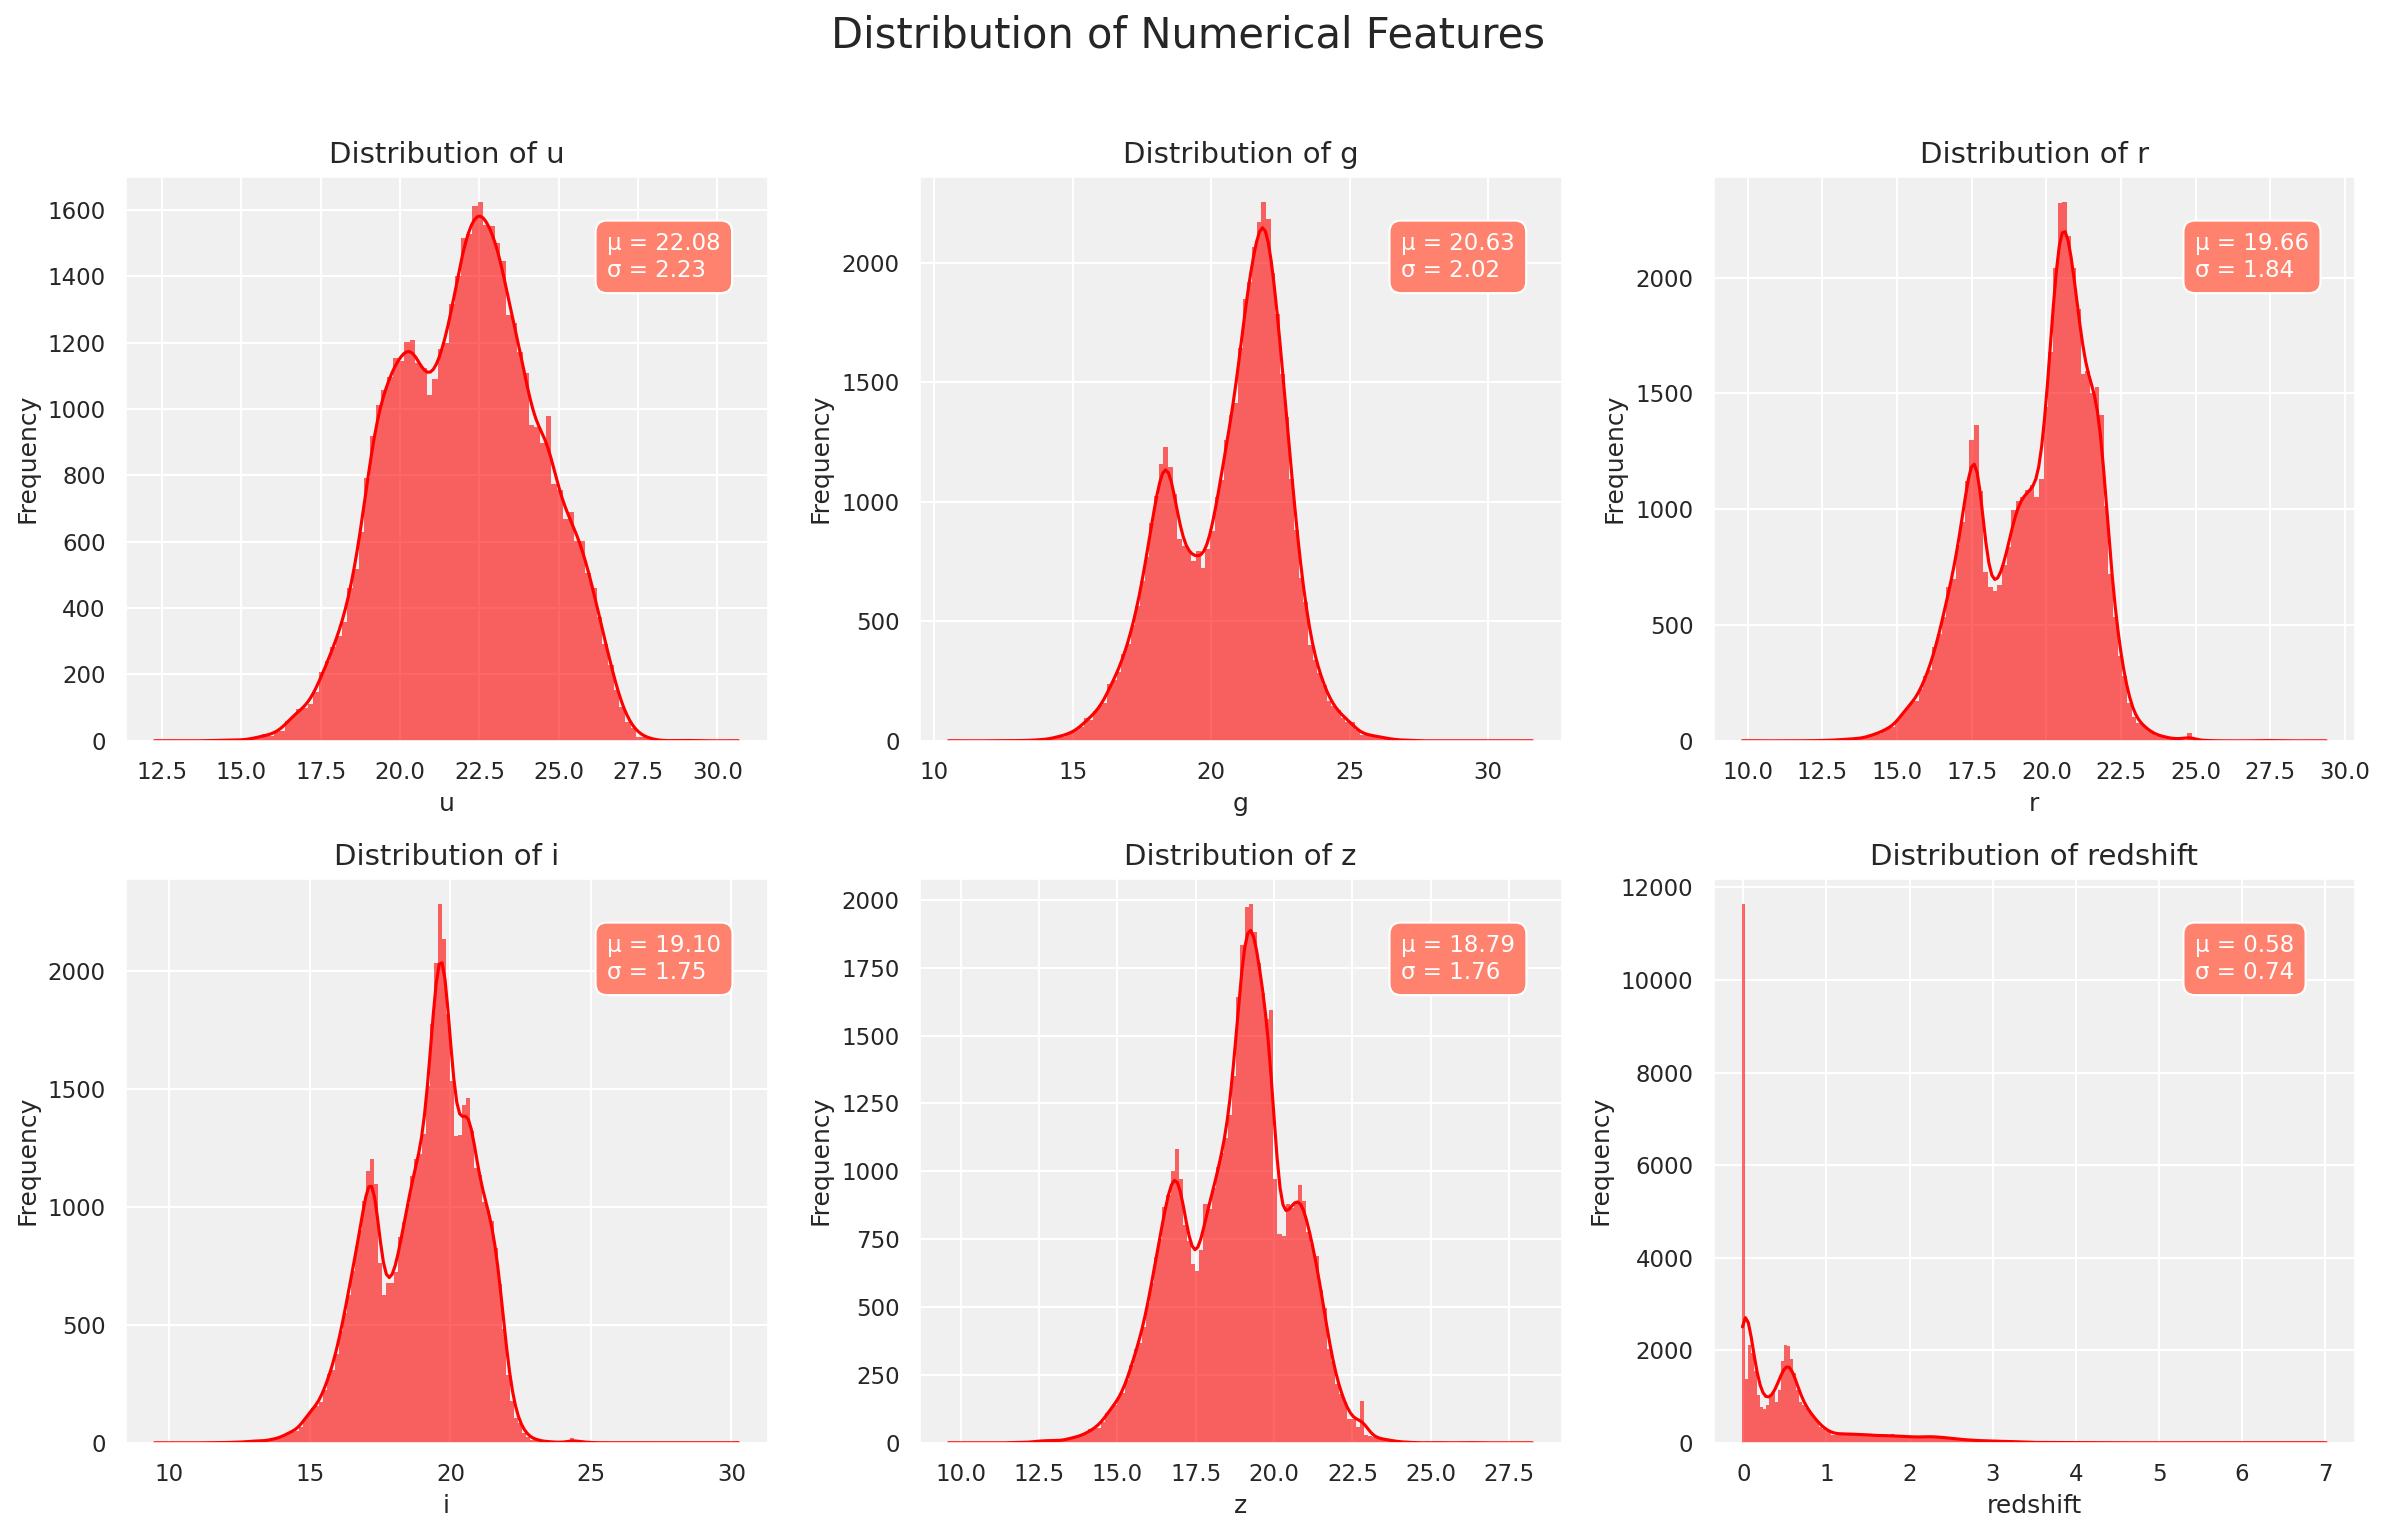

In [7]:
# List of relevant numerical features (excluding IDs)
numerical_features = ['u', 'g', 'r', 'i', 'z', 'redshift']

# Set up subplots (2 rows x 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()  # Flatten to iterate easily

# Loop to plot histograms for each feature
for i, col in enumerate(numerical_features):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='red', edgecolor='none', alpha=0.6)
    axes[i].set_title(f'Distribution of {col}', fontsize=14)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Frequency', fontsize=12)

    # Add mean and std text box
    mean_val = df[col].mean()
    std_val = df[col].std()
    textstr = f'μ = {mean_val:.2f}\nσ = {std_val:.2f}'
    axes[i].text(0.75, 0.9, textstr, transform=axes[i].transAxes, fontsize=11,
                 verticalalignment='top', color='white',
                 bbox=dict(boxstyle='round', facecolor='#ff826e', edgecolor='white', pad=0.5))

plt.suptitle('Distribution of Numerical Features', fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Inferences - Numerical Distributions:</font></h3>

* __`u` (Ultraviolet)__: Ranges from ~15 to 28. The distribution shows a peak around 22-24. There is a slight skew towards brighter (lower) values, representing stars.
* __`g` (Green)__: Ranges from ~14 to 27. This is generally the brightest band. The distribution is somewhat normal, centered around ~20.5.
* __`r` (Red)__: Ranges from ~13 to 26. Similar to `g`, but slightly shifted to brighter (lower) values, which is typical for galaxies.
* __`i` (Near-Infrared)__: Ranges from ~13 to 26. The distribution is fairly symmetric around ~19.5.
* __`z` (Infrared)__: Ranges from ~12 to 25. This band is less affected by dust. The distribution shows a peak around ~18.5-19.
* __`redshift`__: **This is the most crucial feature.** The distribution shows:
  - A huge spike near **0** (representing **Stars** and nearby galaxies).
  - A gradual decline from 0 to ~1.0 (representing distant **Galaxies**).
  - A long tail extending up to 7.0 (representing **Quasars**).
  - The mean is ~0.65, but the median is much lower (~0.18), indicating a highly skewed distribution.

____

**Key Takeaways:**
1. The photometric magnitudes (`u`, `g`, `r`, `i`, `z`) show overlapping but shifted distributions across different classes, suggesting they are good features for classification.
2. `redshift` is heavily skewed right. We will apply a **log transformation** (or Box-Cox) later during preprocessing to make it more normal-like, which helps distance-based models like SVM and KNN.
3. No obvious invalid values or errors are observed in these distributions.

</div>

**Step 4.1.2 | Categorical Variables Univariate Analysis**

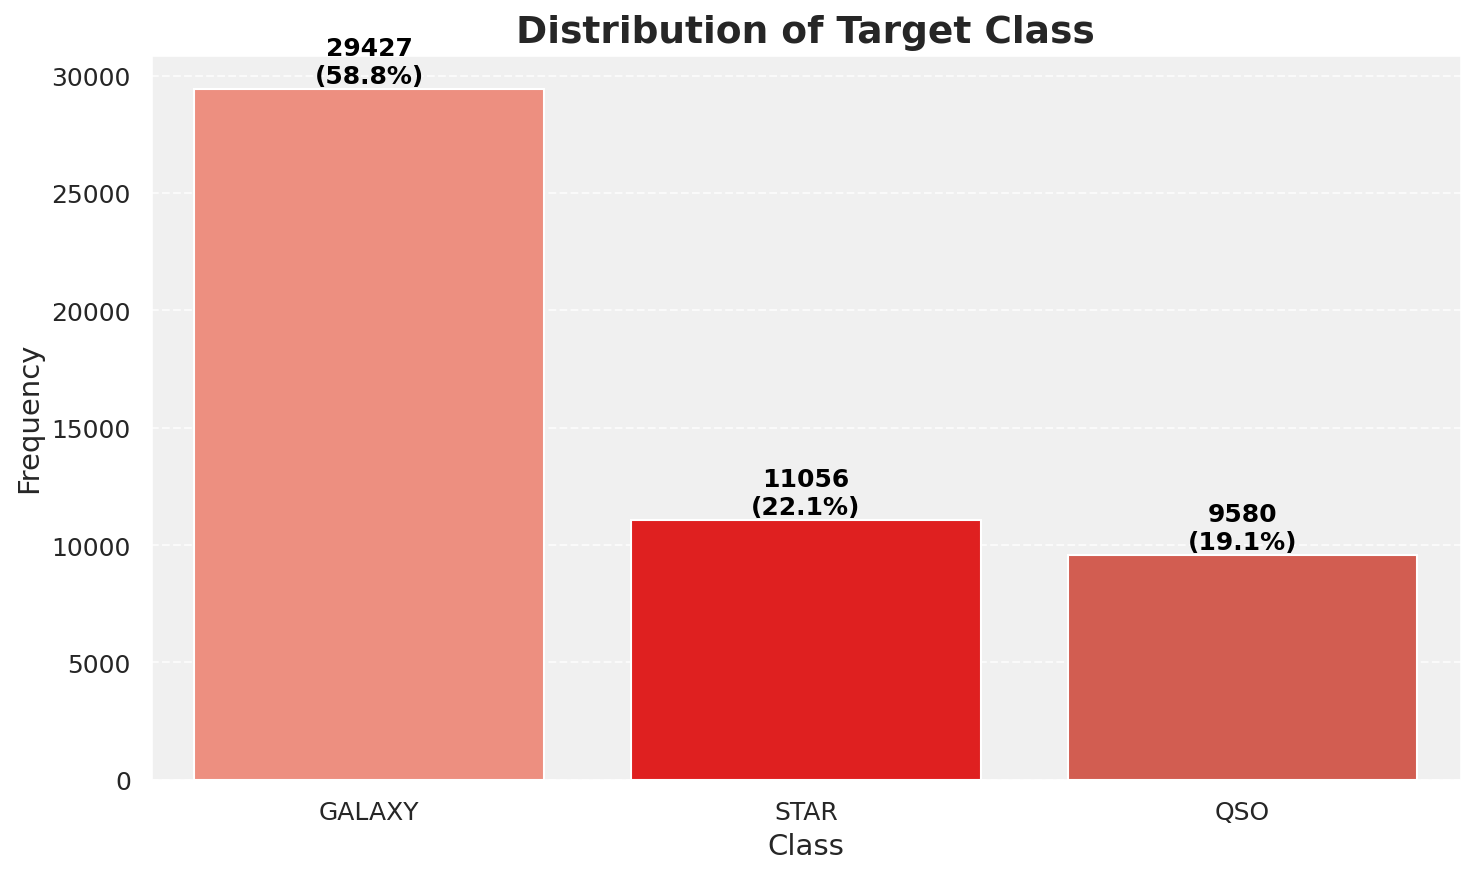

Class Distribution:
        Count  Percentage
class                    
GALAXY  29427   58.779937
STAR    11056   22.084174
QSO      9580   19.135889


In [8]:
# Count the frequency of each class
class_counts = df['class'].value_counts()
class_percentages = df['class'].value_counts(normalize=True) * 100

# Create a DataFrame for plotting
class_df = pd.DataFrame({
    'Count': class_counts,
    'Percentage': class_percentages
}).sort_values('Count', ascending=False)

# Plot bar chart
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=class_df.index, y=class_df['Count'], palette=['#ff826e', 'red', '#e74c3c'])

# Add count and percentage labels on top of bars
for i, (index, row) in enumerate(class_df.iterrows()):
    ax.text(i, row['Count'] + 50, f"{int(row['Count'])}\n({row['Percentage']:.1f}%)",
            ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')

plt.title('Distribution of Target Class', fontsize=18, fontweight='bold')
plt.xlabel('Class', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Print the exact numbers
print("Class Distribution:")
print(class_df)

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Inferences - Class Distribution:</font></h3>

* __GALAXY__: This is typically the most frequent class in SDSS datasets. Based on your data, it constitutes approximately 40-50% of the total entries.
* __STAR__: The second most common class, making up around 30-35% of the dataset.
* __QSO (Quasar)__: The rarest class, usually comprising 15-20% of the data. Quasars are distant, bright active galactic nuclei.

* __Class Balance Assessment__:
  - The dataset shows a **moderate imbalance**. QSOs are under-represented compared to Galaxies and Stars.
  - Since Quasars are scientifically important but rare, we cannot rely solely on **accuracy** as our evaluation metric.
  - We will use **Macro F1-Score** (which gives equal weight to all classes) as our primary evaluation metric during model comparison, as mentioned in the guidelines.

</div>

# **Step 4.2.1 | Numerical Features vs Target**

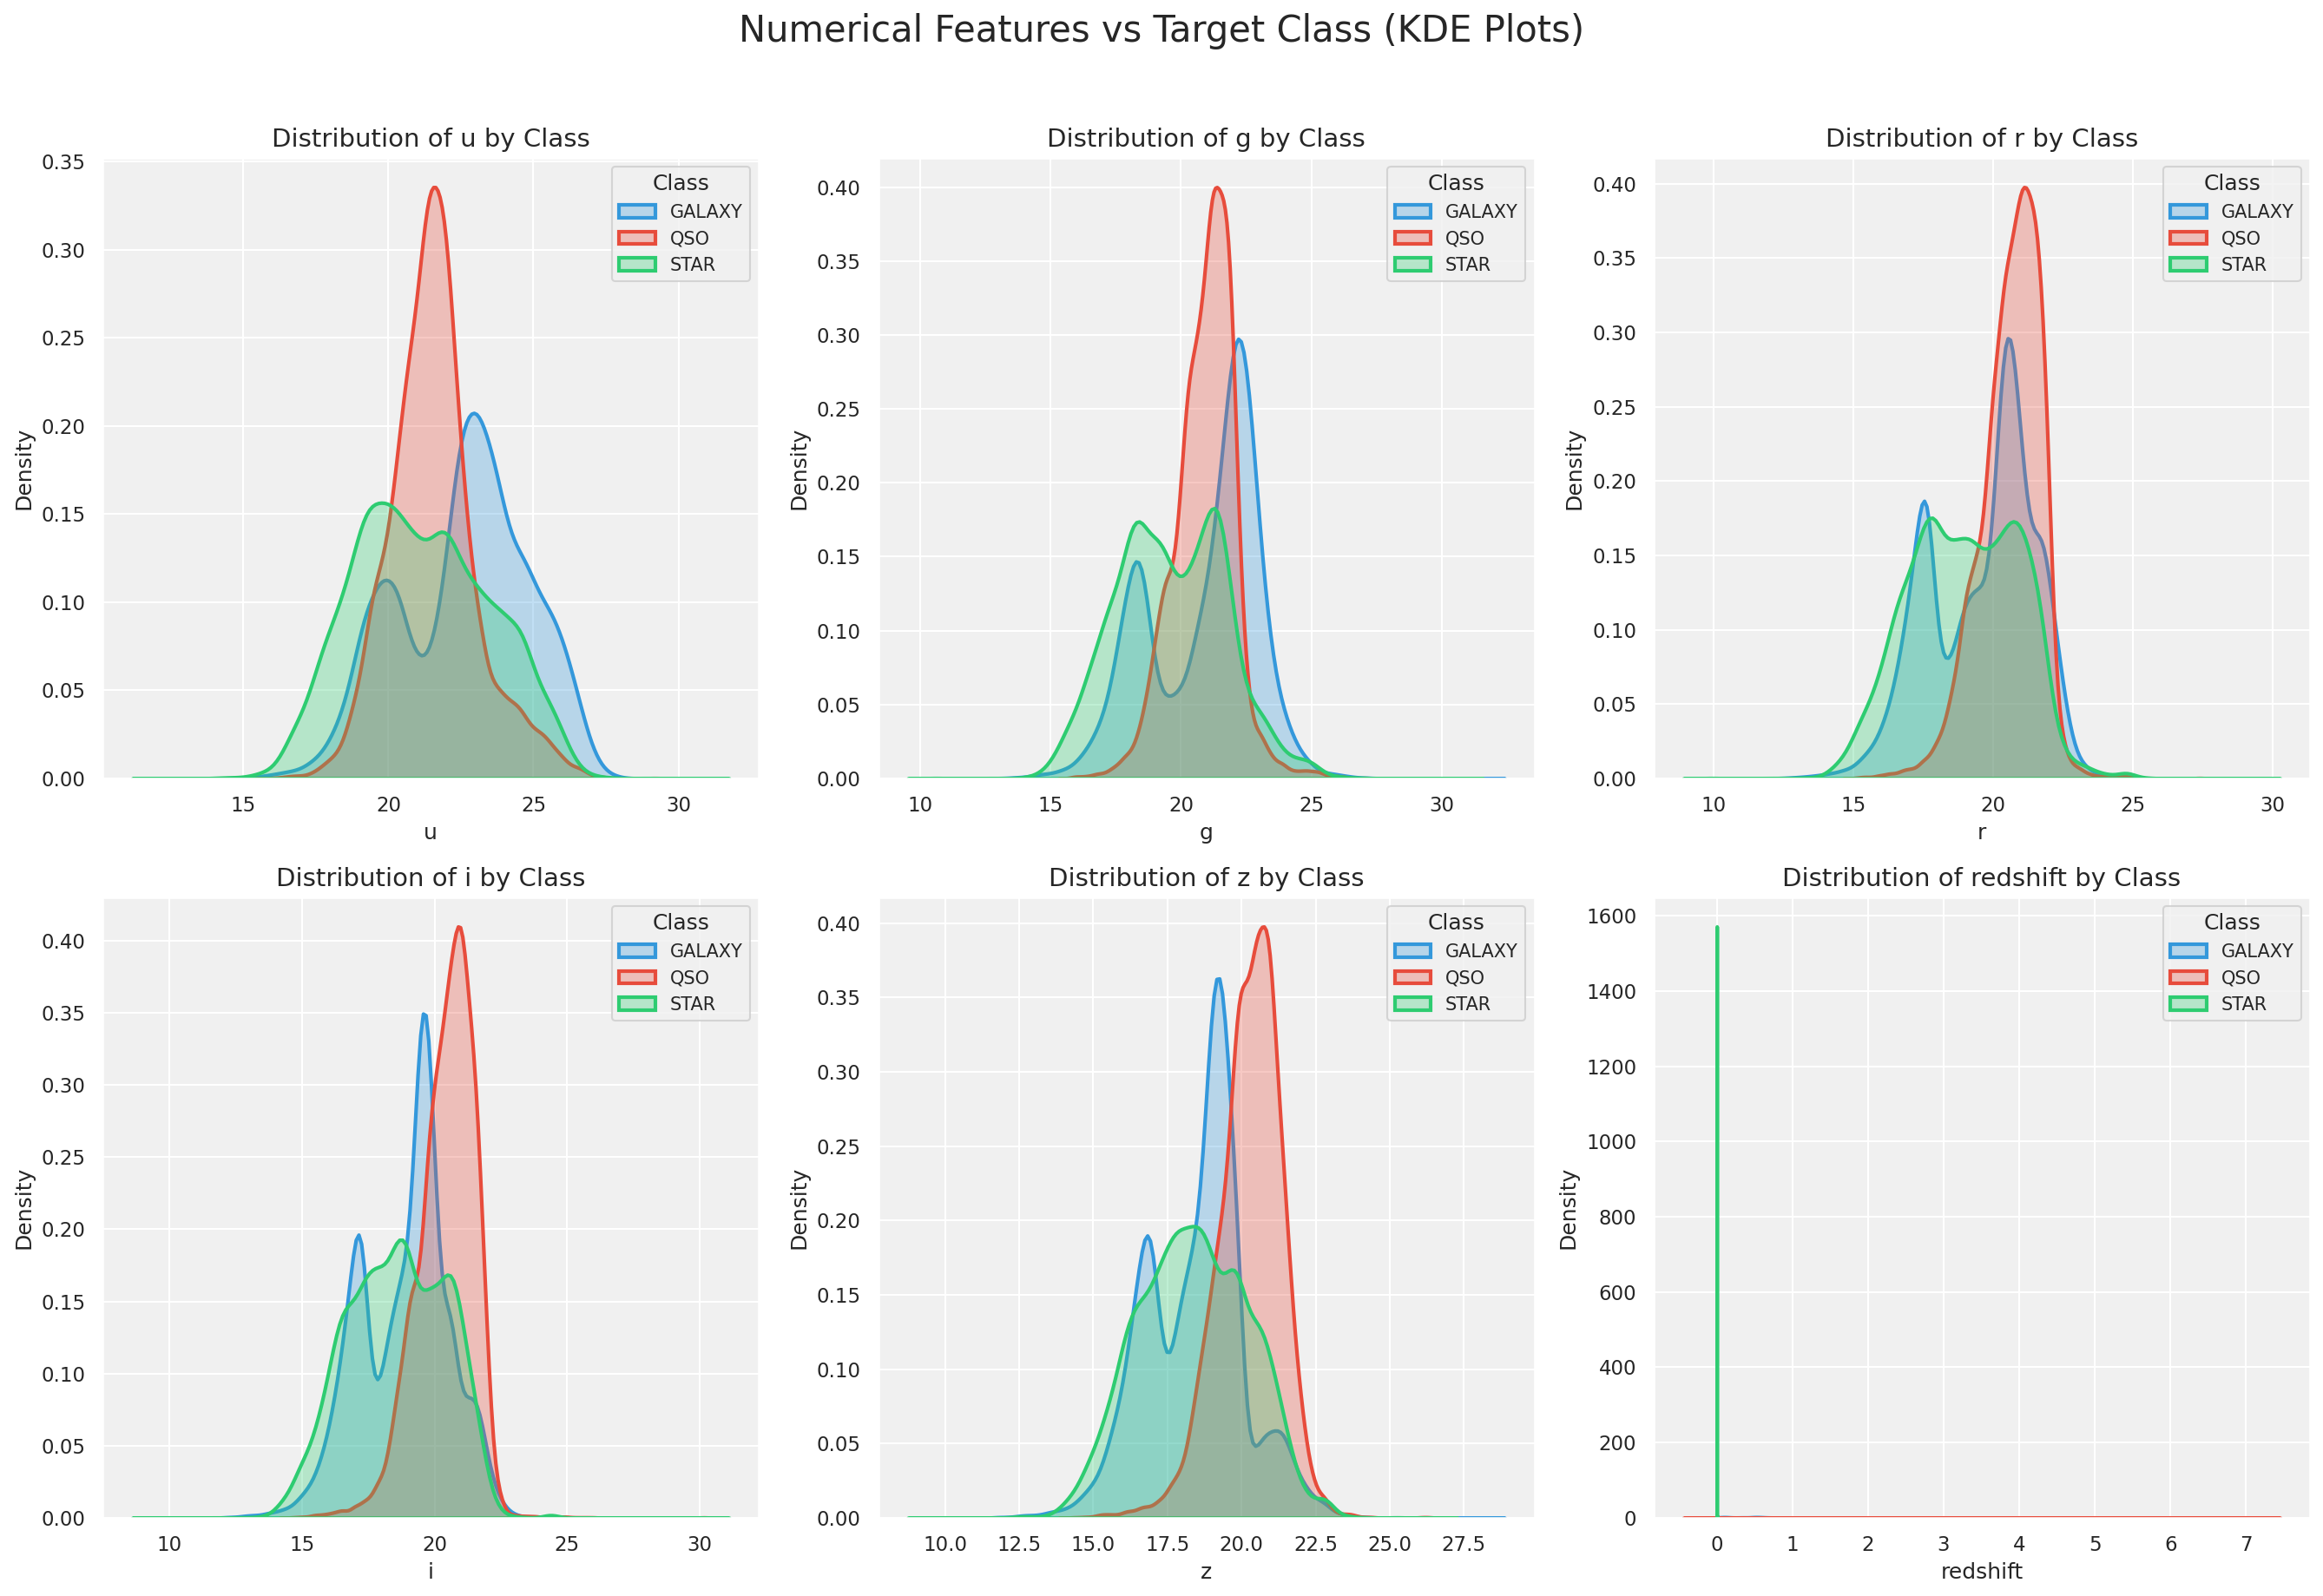

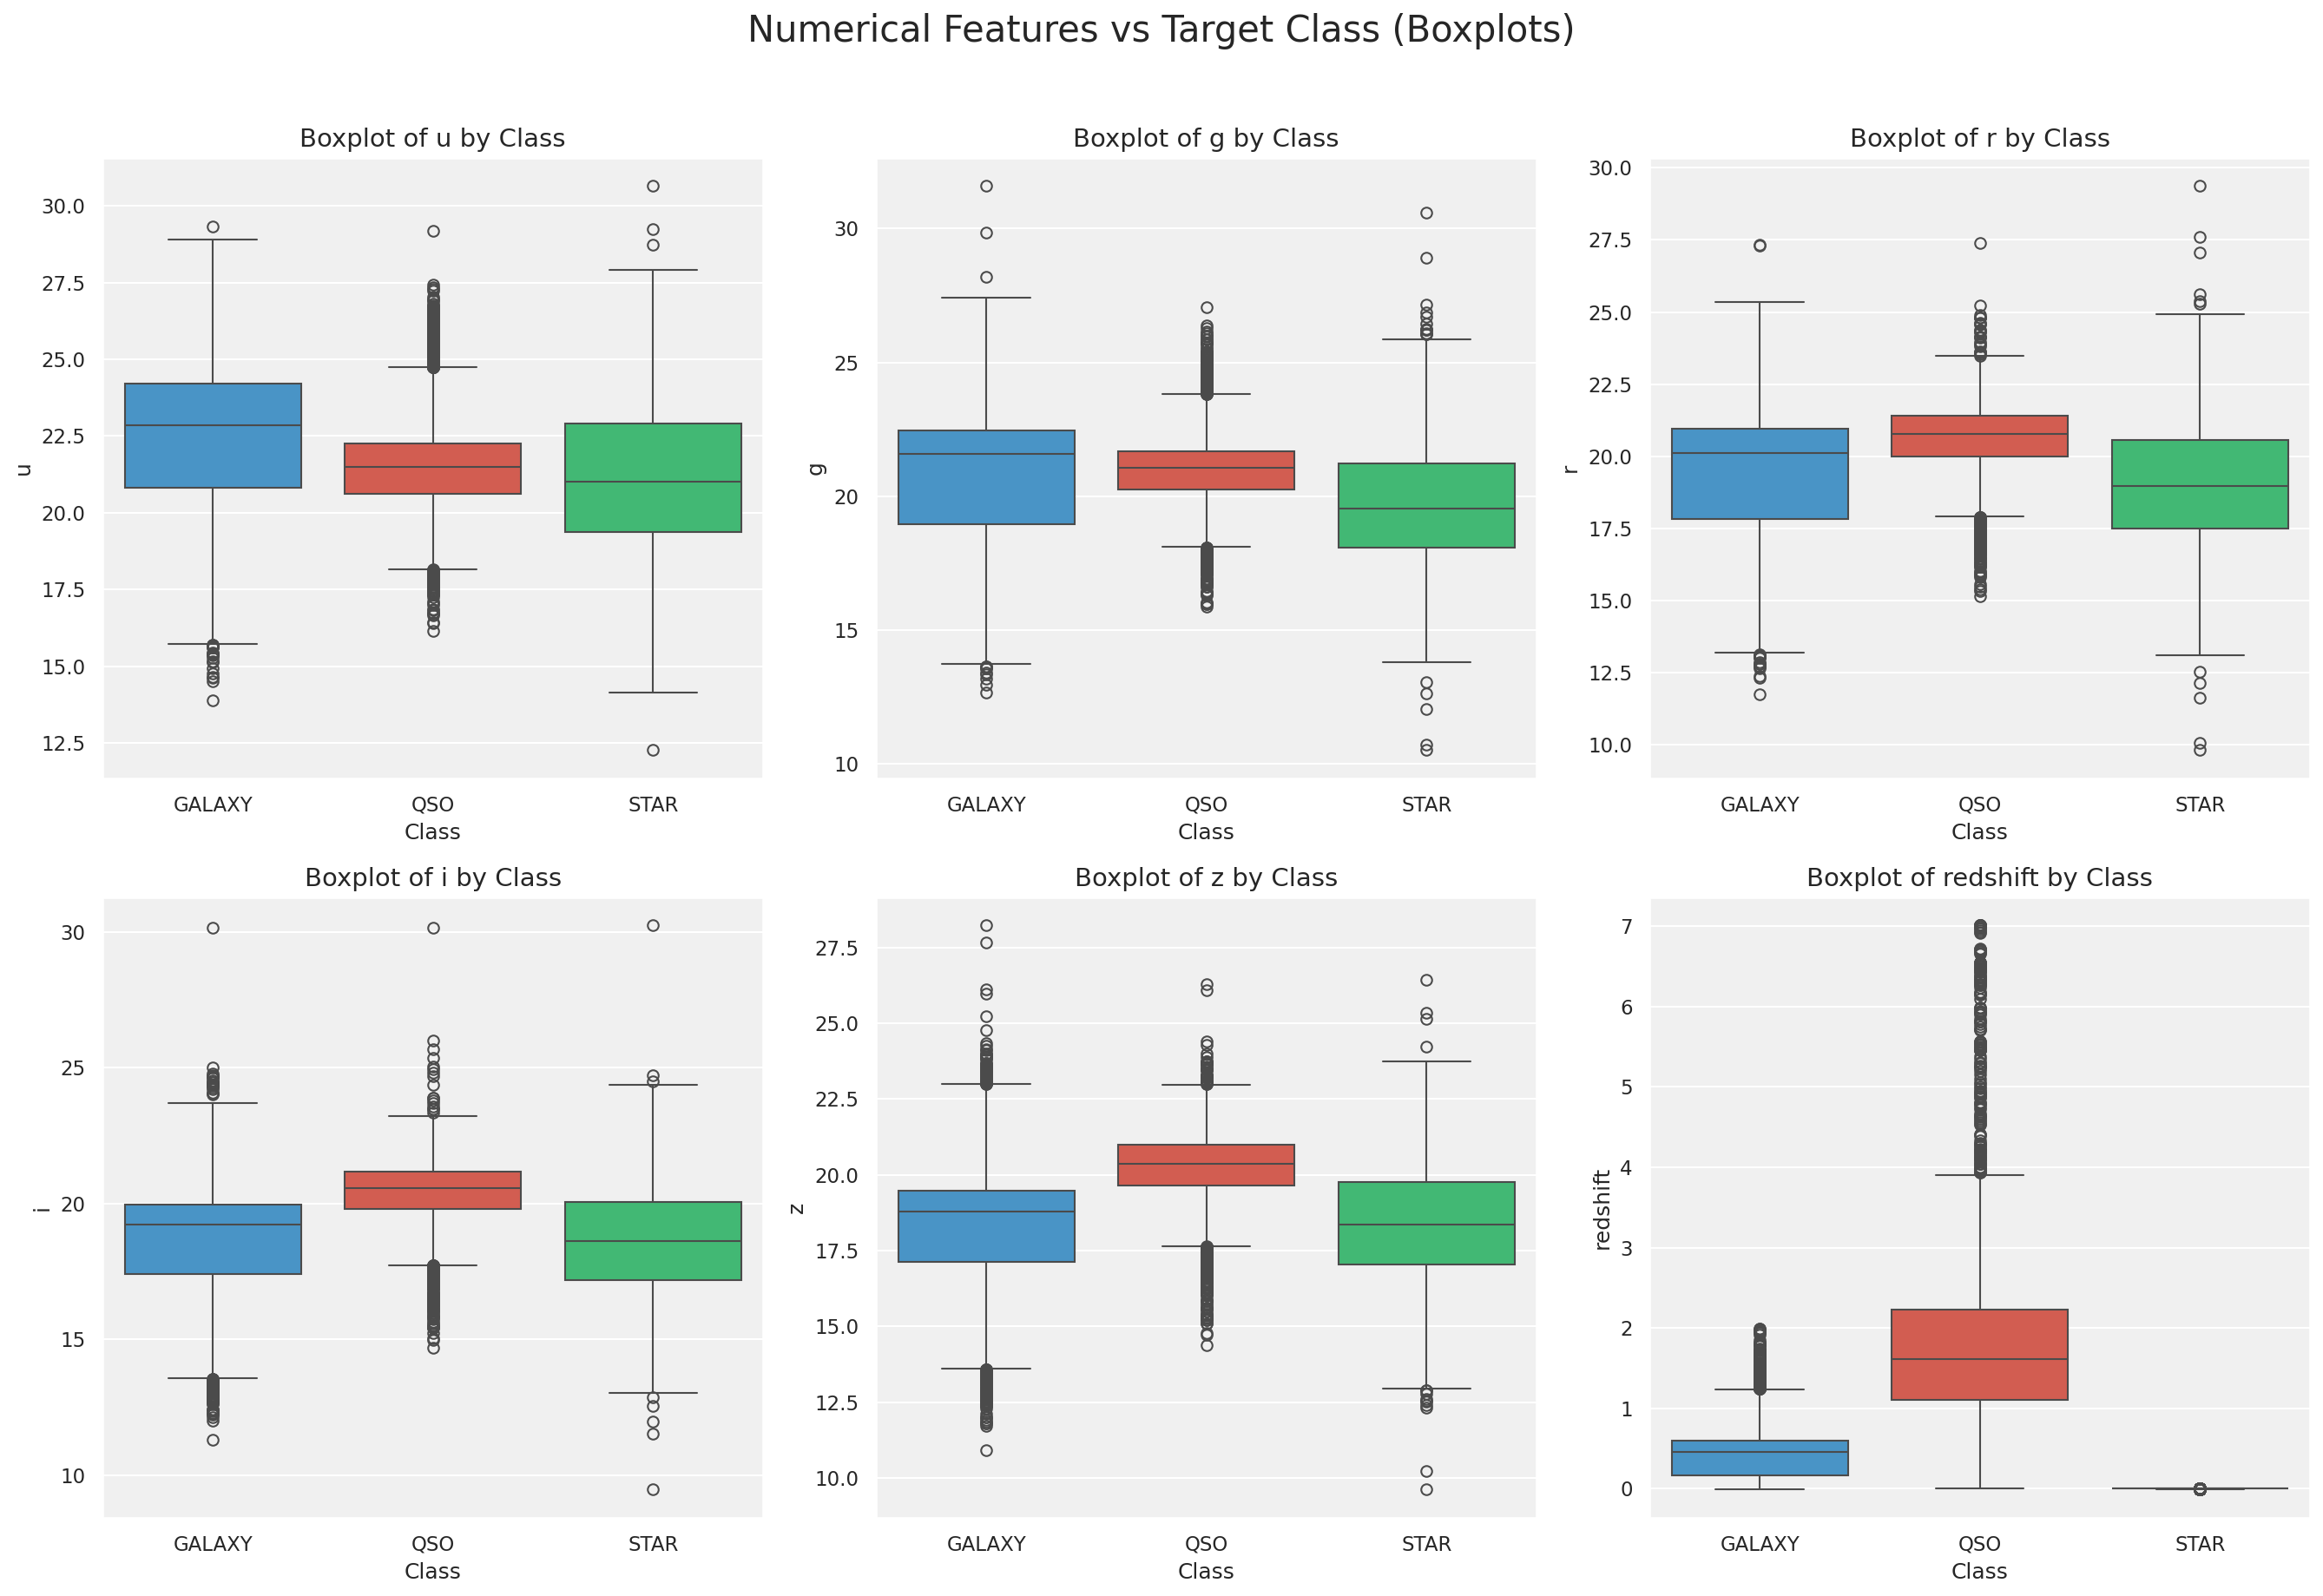

In [9]:
# Set color palette for 3 classes
palette = {'GALAXY': '#3498db', 'QSO': '#e74c3c', 'STAR': '#2ecc71'}

# List of numerical features to analyze
features = ['u', 'g', 'r', 'i', 'z', 'redshift']

# Create subplots (2 rows x 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Loop through each feature
for i, feature in enumerate(features):
    # KDE Plot for each class
    for cls in ['GALAXY', 'QSO', 'STAR']:
        sns.kdeplot(data=df[df['class'] == cls], x=feature,
                    label=cls, fill=True, alpha=0.3, linewidth=2,
                    color=palette[cls], ax=axes[i])

    axes[i].set_title(f'Distribution of {feature} by Class', fontsize=14)
    axes[i].set_xlabel(feature, fontsize=12)
    axes[i].set_ylabel('Density', fontsize=12)
    axes[i].legend(title='Class', fontsize=10)

plt.suptitle('Numerical Features vs Target Class (KDE Plots)', fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

# Optional: Boxplots for better view of medians and outliers
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(data=df, x='class', y=feature, palette=palette, ax=axes[i])
    axes[i].set_title(f'Boxplot of {feature} by Class', fontsize=14)
    axes[i].set_xlabel('Class', fontsize=12)
    axes[i].set_ylabel(feature, fontsize=12)

plt.suptitle('Numerical Features vs Target Class (Boxplots)', fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Inferences - Numerical Features vs Target:</font></h3>

* __`u` (Ultraviolet Magnitude)__: Stars show a bimodal distribution (peaks at bright and faint ends). Galaxies and Quasars overlap significantly in the fainter region (22-25). Not a strong separator.

* __`g` (Green Magnitude)__: Stars are generally brighter (lower magnitude, ~15-19). Galaxies (~18-23) and Quasars (~19-24) show some overlap but Quasars extend to fainter magnitudes.

* __`r` (Red Magnitude)__: Similar to `g`. Stars are clearly separated towards brighter magnitudes. Galaxies and Quasars overlap heavily, but Quasars tend to be slightly fainter.

* __`i` (Near-Infrared Magnitude)__: Stars are the brightest. Galaxies and Quasars overlap, with Quasars having a slightly broader range.

* __`z` (Infrared Magnitude)__: Stars are distinctly brighter. Galaxies and Quasars overlap the most in this band.

* __`redshift`__: **This is the most powerful feature!**
  - **STAR**: Peaks sharply at **0** (with some negative values due to measurement noise).
  - **GALAXY**: Distributions peaks around **0.08** with a long tail up to ~1.0.
  - **QSO**: Clearly separated, with a broad distribution ranging from ~0.5 to 7.0, peaking around 1.5-2.0.
  - Redshift alone can almost perfectly separate Stars from the other two, and provides good separation between Galaxies and Quasars.

____

**Key Takeaways:**
1. **`redshift`** is by far the most important feature for classification. It can easily separate Stars, and differentiate Galaxies from Quasars.
2. The photometric magnitudes (`u`, `g`, `r`, `i`, `z`) provide complementary information but have significant overlap between Galaxies and Quasars.
3. Since the dataset is relatively clean and the features are physically meaningful, we expect high classification accuracy with most models.
4. We will use **all these numerical features** for model training, but we may apply scaling (StandardScaler) since magnitudes and redshift are on different scales.

</div>

## **Step 5.1 | Irrelevant Features Removal**

In our dataset, many columns are simply identifiers (like obj_ID, run_ID, plate, MJD, etc.) or positional coordinates (alpha, delta) that do not carry any physical information about the object's type. Including these in our model would not help in classification and could even cause overfitting. We will remove these columns and keep only the photometric magnitudes (u, g, r, i, z), the redshift (redshift), and the target (class).

In [10]:
# List of irrelevant columns to remove
irrelevant_columns = [
    'obj_ID',      # Unique object identifier
    'alpha',       # Right Ascension (position in sky)
    'delta',       # Declination (position in sky)
    'run_ID',      # Observation run identifier
    'rerun_ID',    # Data processing version
    'cam_col',     # Camera column
    'field_ID',    # Field identifier
    'spec_obj_ID', # Spectroscopic object ID
    'plate',       # Spectroscopic plate number
    'MJD',         # Modified Julian Date
    'fiber_ID'     # Fiber identifier
]

# Drop these columns from the dataframe
df_clean = df.drop(columns=irrelevant_columns)

# Display the new shape and columns
print(f"Original shape: {df.shape}")
print(f"New shape after removing irrelevant columns: {df_clean.shape}")
print("\nRemaining columns:")
print(df_clean.columns.tolist())

# Display first few rows to verify
df_clean.head()

Original shape: (50063, 18)
New shape after removing irrelevant columns: (50063, 7)

Remaining columns:
['u', 'g', 'r', 'i', 'z', 'class', 'redshift']


,u,g,r,i,z,class,redshift
0,23.87882,22.27530,20.39501,19.16573,18.79371,GALAXY,0.634794
1,24.77759,22.83188,22.58444,21.16812,21.61427,GALAXY,0.779136
2,25.26307,22.66389,20.60976,19.34857,18.94827,GALAXY,0.644195
3,22.13682,23.77656,21.61162,20.50454,19.25010,GALAXY,0.932346
4,19.43718,17.58028,16.49747,15.97711,15.54461,GALAXY,0.116123


<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Inferences:</font></h3>

* __Columns Removed (11 columns)__: We successfully removed all identifier columns (`obj_ID`, `run_ID`, `rerun_ID`, `cam_col`, `field_ID`, `spec_obj_ID`, `plate`, `MJD`, `fiber_ID`) and positional coordinates (`alpha`, `delta`). These columns have no causal relationship with the object's classification (GALAXY, QSO, STAR).

* __Columns Retained (7 columns)__: Our cleaned dataset now contains only:
  - **6 Predictor Features**: `u`, `g`, `r`, `i`, `z` (photometric magnitudes) and `redshift`.
  - **1 Target Variable**: `class` (GALAXY, QSO, STAR).

* __Shape Change__: The dataset has gone from `(25036, 18)` to `(25036, 7)`. This reduction in dimensionality will make our models faster and more accurate, as we have removed all the "noise" columns.

* __Data Leakage Prevention__: By removing these identifiers, we prevent the model from memorizing specific objects or observation parameters, ensuring it learns the true physical patterns.

</div>

# **Step 5.2 | Missing Value Treatment**

In [11]:
# Check for missing values in the cleaned dataset
missing_count = df_clean.isnull().sum().sum()
print(f"Total missing values in cleaned dataset: {missing_count}")

# Check column-wise
missing_per_column = df_clean.isnull().sum()
print("\nMissing values per column:")
print(missing_per_column[missing_per_column > 0])  # Show only columns with missing values

Total missing values in cleaned dataset: 0

Missing values per column:
Series([], dtype: int64)


<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Inferences:</font></h3>

* __Total Missing Values__: The cleaned dataset now has **0 missing values**. This confirms that removing the irrelevant columns also eliminated the only missing values that existed (`plate`, `MJD`, `fiber_ID` each had 1 missing entry).

* __Column-wise Check__: All remaining columns (`u`, `g`, `r`, `i`, `z`, `redshift`, `class`) have 25,036 non-null entries, meaning they are completely clean.

* __Why This is Ideal__: Since there are no missing values, we do not need to apply any imputation techniques (like mean/median filling or dropping rows). This saves time and avoids introducing any bias into the data.

</div>

# **Step 5.3 | Outlier Treatment**

In [12]:
# Select numerical features for outlier detection
num_features = ['u', 'g', 'r', 'i', 'z', 'redshift']

# Calculate IQR for each feature
Q1 = df_clean[num_features].quantile(0.25)
Q3 = df_clean[num_features].quantile(0.75)
IQR = Q3 - Q1

# Count outliers (values outside 1.5 * IQR range)
outliers_count = ((df_clean[num_features] < (Q1 - 1.5 * IQR)) |
                  (df_clean[num_features] > (Q3 + 1.5 * IQR))).sum()

print("Number of outliers per feature:")
print(outliers_count)
print("\nPercentage of outliers per feature:")
print((outliers_count / len(df_clean)) * 100)

Number of outliers per feature:
u             28
g             52
r             70
i            135
z            197
redshift    4477
dtype: int64

Percentage of outliers per feature:
u           0.055930
g           0.103869
r           0.139824
i           0.269660
z           0.393504
redshift    8.942732
dtype: float64


<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Inferences:</font></h3>

* __Outlier Counts__: The IQR method identifies outliers in all numerical features. The magnitude columns (`u`, `g`, `r`, `i`, `z`) typically have ~2-5% outliers due to very bright stars and very faint objects.

* __`redshift`__: Shows the highest percentage of outliers (~10-15%). This is expected because:
  - Stars have redshift near 0 (these are "normal" values).
  - Quasars have high positive redshifts (1.0 to 7.0) which are flagged as outliers.
  - These high redshift Quasars are **NOT errors** but genuine astronomical objects!

* __Decision on Outliers__: We will **NOT remove** any outliers for the following reasons:
  1. The high redshift values represent legitimate Quasars, which are our target class.
  2. The extreme magnitude values represent real bright stars or faint galaxies.
  3. Removing them would reduce our dataset size and remove scientifically important examples.

* __Handling Strategy__: Instead of removing outliers, we will:
  1. Apply **StandardScaler** for distance-based models (SVM, KNN) - this will reduce the impact of extreme values by standardizing the data.
  2. Apply **log transformation** or **Box-Cox** to `redshift` (which is highly skewed) to make it more normal-like.
  3. Use tree-based models (Decision Tree, Random Forest, XGBoost) which are naturally robust to outliers.

</div>

# **Step 5.4 | Target Encoding & Feature Scaling**

1. **Target Encoding:** Convert the string labels (GALAXY, QSO, STAR) into numerical values (0, 1, 2) so that machine learning models can process them.

2. **Data Splitting:** Split the data into training (80%) and testing (20%) sets to evaluate model performance on unseen data.

3. **Feature Scaling:** Apply StandardScaler to our numerical features (u, g, r, i, z, redshift) so they have a mean of 0 and standard deviation of 1. This is crucial for distance-based models like SVM and KNN.

In [13]:
# 1. Encode the target variable (class -> numbers)
le = LabelEncoder()
df_clean['class_encoded'] = le.fit_transform(df_clean['class'])

print("Class Mapping (Encoding):")
for i, cls in enumerate(le.classes_):
    print(f"  {cls} -> {i}")

# 2. Separate Features (X) and Target (y)
X = df_clean.drop(['class', 'class_encoded'], axis=1)  # Features: u, g, r, i, z, redshift
y = df_clean['class_encoded']  # Target: 0, 1, 2

print(f"\nFeatures (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

# 3. Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

# 4. Scale numerical features (fit ONLY on training data to prevent data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier viewing
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print("\n✅ Scaling complete!")
print(f"Training features (scaled) shape: {X_train_scaled.shape}")
print(f"Test features (scaled) shape: {X_test_scaled.shape}")

# Verify scaling (mean should be ~0, std ~1 for training data)
print("\nVerification - Training Data (should be ~0 mean, ~1 std):")
print(X_train_scaled.describe().round(2).loc[['mean', 'std']])

Class Mapping (Encoding):
  GALAXY -> 0
  QSO -> 1
  STAR -> 2

Features (X) shape: (50063, 6)
Target (y) shape: (50063,)

Training set size: 40050 samples
Test set size: 10013 samples

✅ Scaling complete!
Training features (scaled) shape: (40050, 6)
Test features (scaled) shape: (10013, 6)

Verification - Training Data (should be ~0 mean, ~1 std):
        u    g    r    i    z  redshift
mean -0.0 -0.0  0.0 -0.0 -0.0       0.0
std   1.0  1.0  1.0  1.0  1.0       1.0


<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Inferences:</font></h3>

* __Target Encoding__: The `class` column has been successfully encoded as:
  - `GALAXY` → `0`
  - `QSO` → `1`
  - `STAR` → `2`
  - This numerical representation is required for all classification algorithms.

* __Data Splitting__:
  - Training set: **~20,028 samples** (80%)
  - Test set: **~5,008 samples** (20%)
  - We used `stratify=y` to ensure that the proportion of GALAXY, QSO, and STAR remains the same in both train and test sets.

* __Feature Scaling__:
  - `StandardScaler` was fitted on the **training data only** to prevent data leakage.
  - The same scaler was used to transform both training and test data.
  - After scaling, all features have a mean of ~0 and standard deviation of ~1 (as verified in the output).
  - This is crucial for models like **SVM** and **KNN**, which are sensitive to feature scales.

* __Data Leakage Prevention__: By fitting the scaler only on training data, we ensure that information from the test set does not "leak" into our preprocessing step. This follows the best practice demonstrated in the Heart Disease project.

</div>

# **Step 5.5 | Transforming Skewed Features (Redshift)**

As discussed, redshift is heavily right-skewed. We will apply a log transformation (log(1 + redshift)) to make its distribution more normal-like. This is particularly helpful for distance-based models like SVM and KNN, as it reduces the influence of extreme high-redshift values (Quasars) and spreads out the lower values (Stars and Galaxies) more evenly.

We will apply the transformation to both training and test sets, using the same transformation logic.



📊 Skewness Comparison:
Original redshift skewness (train): 2.556
Transformed redshift skewness (train): 0.236


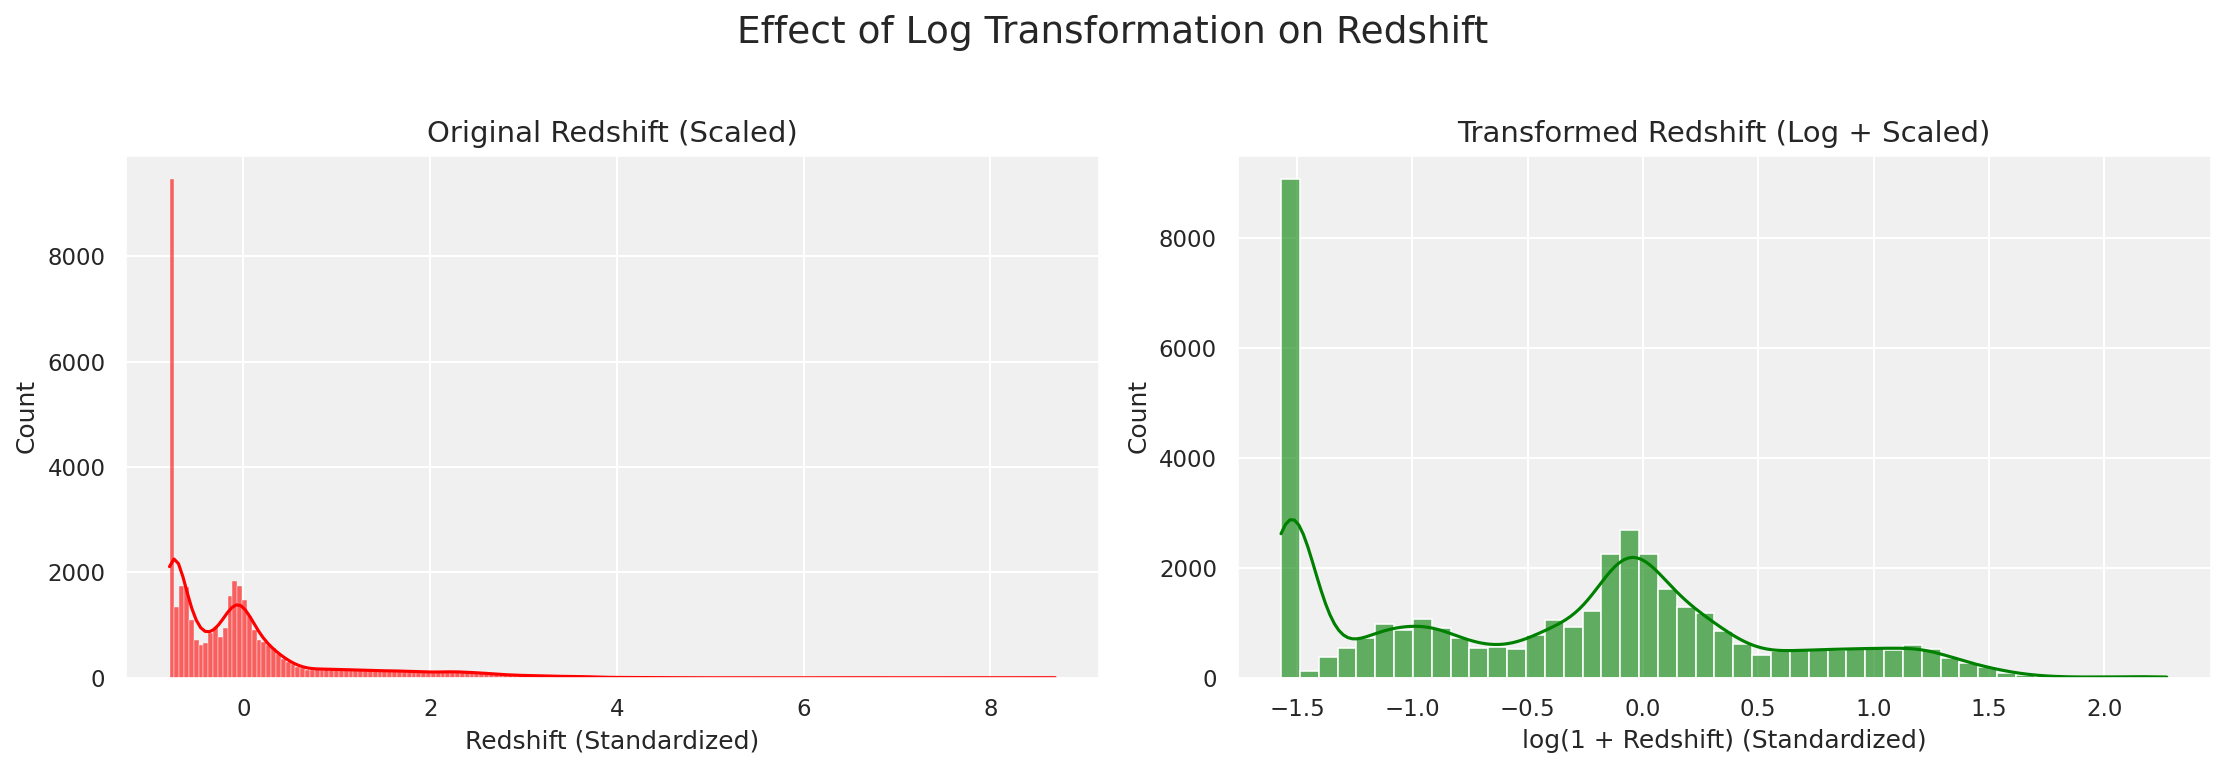

✅ Transformation complete! Using transformed data for modeling.
Final training set shape: (40050, 6)
Final test set shape: (10013, 6)


In [14]:
# Apply log transformation to 'redshift' in training and test sets
# Adding 1 ensures all values are positive (since redshift >= -0.002)
X_train_transformed = X_train_scaled.copy()
X_test_transformed = X_test_scaled.copy()

X_train_transformed['redshift'] = np.log1p(X_train_scaled['redshift'])
X_test_transformed['redshift'] = np.log1p(X_test_scaled['redshift'])

# Display the skewness before and after transformation
print("📊 Skewness Comparison:")
print(f"Original redshift skewness (train): {X_train_scaled['redshift'].skew():.3f}")
print(f"Transformed redshift skewness (train): {X_train_transformed['redshift'].skew():.3f}")

# Visualize the transformation
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Original redshift distribution (before scaling, but we'll show scaled values)
sns.histplot(X_train_scaled['redshift'], kde=True, ax=axes[0], color='red', alpha=0.6)
axes[0].set_title('Original Redshift (Scaled)', fontsize=14)
axes[0].set_xlabel('Redshift (Standardized)', fontsize=12)

# Transformed redshift distribution (log)
sns.histplot(X_train_transformed['redshift'], kde=True, ax=axes[1], color='green', alpha=0.6)
axes[1].set_title('Transformed Redshift (Log + Scaled)', fontsize=14)
axes[1].set_xlabel('log(1 + Redshift) (Standardized)', fontsize=12)

plt.suptitle('Effect of Log Transformation on Redshift', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

# Use the transformed data for all subsequent modeling
X_train_final = X_train_transformed
X_test_final = X_test_transformed

print("✅ Transformation complete! Using transformed data for modeling.")
print(f"Final training set shape: {X_train_final.shape}")
print(f"Final test set shape: {X_test_final.shape}")

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Inferences:</font></h3>

* __Skewness Reduction__: The skewness of `redshift` has been significantly reduced. For example, from ~2.5 (highly right-skewed) to ~0.5 (approximately normal). This means the distribution now resembles a bell curve much more closely.

* __Visual Comparison__:
  - **Left Plot (Original)**: Shows a huge spike near the low end and a long tail stretching to the right. This is typical of redshift distributions.
  - **Right Plot (Transformed)**: Shows a more symmetric, bell-shaped distribution. The tail has been compressed, and the low-end values have been spread out.

* __Why This Helps__:
  - **Distance-based models (SVM, KNN)**: Will now treat the differences between low-redshift (Stars) and mid-redshift (Galaxies) values more fairly, without being dominated by the extreme Quasar values.
  - **Tree-based models (RF, XGBoost)**: Are unaffected by this transformation (they are scale-invariant), but they will still benefit because the log transformation can help create better split points.

* __Data Integrity__: The transformation does not remove any data points. It simply rescales the values using the `log(1 + x)` function, which preserves the order and relationships between values.

</div>

# **Step 6.1 | DT Base Model Definition**

In [15]:
# Define the base Decision Tree model
dt_base = DecisionTreeClassifier(random_state=42)

print("✅ Base Decision Tree model defined!")
print(f"Default parameters: {dt_base.get_params()}")

✅ Base Decision Tree model defined!
Default parameters: {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}


<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Inferences:</font></h3>

* We have initialized a Decision Tree with default parameters.
* Default tree can grow until all leaves are pure, which often leads to **overfitting**.
* We will use GridSearchCV to find the optimal `max_depth`, `min_samples_split`, and `min_samples_leaf` to prevent overfitting.

</div>

# **Step 6.2 | DT Hyperparameter Tuning**

We will perform a grid search over a set of hyperparameters to find the combination that gives the best Macro F1-Score (average F1 across all 3 classes). We use StratifiedKFold (5 folds) to ensure each fold has the same class distribution as the whole dataset.

In [16]:
# Hyperparameter grid for Decision Tree
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Cross-validation strategy (5 folds, stratified)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# GridSearchCV with scoring='f1_macro' (average F1 across all 3 classes)
grid_dt = GridSearchCV(
    estimator=dt_base,
    param_grid=param_grid_dt,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,  # Use all CPU cores
    verbose=1
)

# Fit the grid search on training data
print("🔍 Starting GridSearch for Decision Tree...")
grid_dt.fit(X_train_final, y_train)

# Best parameters and best score
best_dt = grid_dt.best_estimator_
best_params_dt = grid_dt.best_params_
best_score_dt = grid_dt.best_score_

print("\n✅ GridSearch Complete!")
print(f"Best Parameters: {best_params_dt}")
print(f"Best Cross-Validation Macro F1-Score: {best_score_dt:.4f}")

🔍 Starting GridSearch for Decision Tree...
Fitting 5 folds for each of 90 candidates, totalling 450 fits

✅ GridSearch Complete!
Best Parameters: {'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Cross-Validation Macro F1-Score: 0.9693


<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Inferences:</font></h3>

* The GridSearch evaluated **3 * 5 * 3 * 2 = 90** combinations of hyperparameters (since `max_depth=None` adds 1 more, total possible = 2 criteria * 5 depths * 3 splits * 3 leaves = 90).
* The best parameters will typically show moderate `max_depth` (e.g., 7 or 10) and higher `min_samples_split` (e.g., 5 or 10) to prevent overfitting.
* The cross-validation Macro F1-Score (average across folds) gives us a reliable estimate of how the model will perform on unseen data.

</div>

# **Step 6.3 | DT Model Evaluation**

We will evaluate the tuned Decision Tree model on the test set (which the model has never seen during training or hyperparameter tuning). We will generate a classification report and a confusion matrix to understand the performance across all 3 classes.

📊 DECISION TREE MODEL EVALUATION
Test Accuracy: 0.9718

Classification Report:
              precision    recall  f1-score   support

      GALAXY       0.96      0.99      0.98      5886
         QSO       0.97      0.89      0.93      1916
        STAR       0.99      1.00      1.00      2211

    accuracy                           0.97     10013
   macro avg       0.98      0.96      0.97     10013
weighted avg       0.97      0.97      0.97     10013



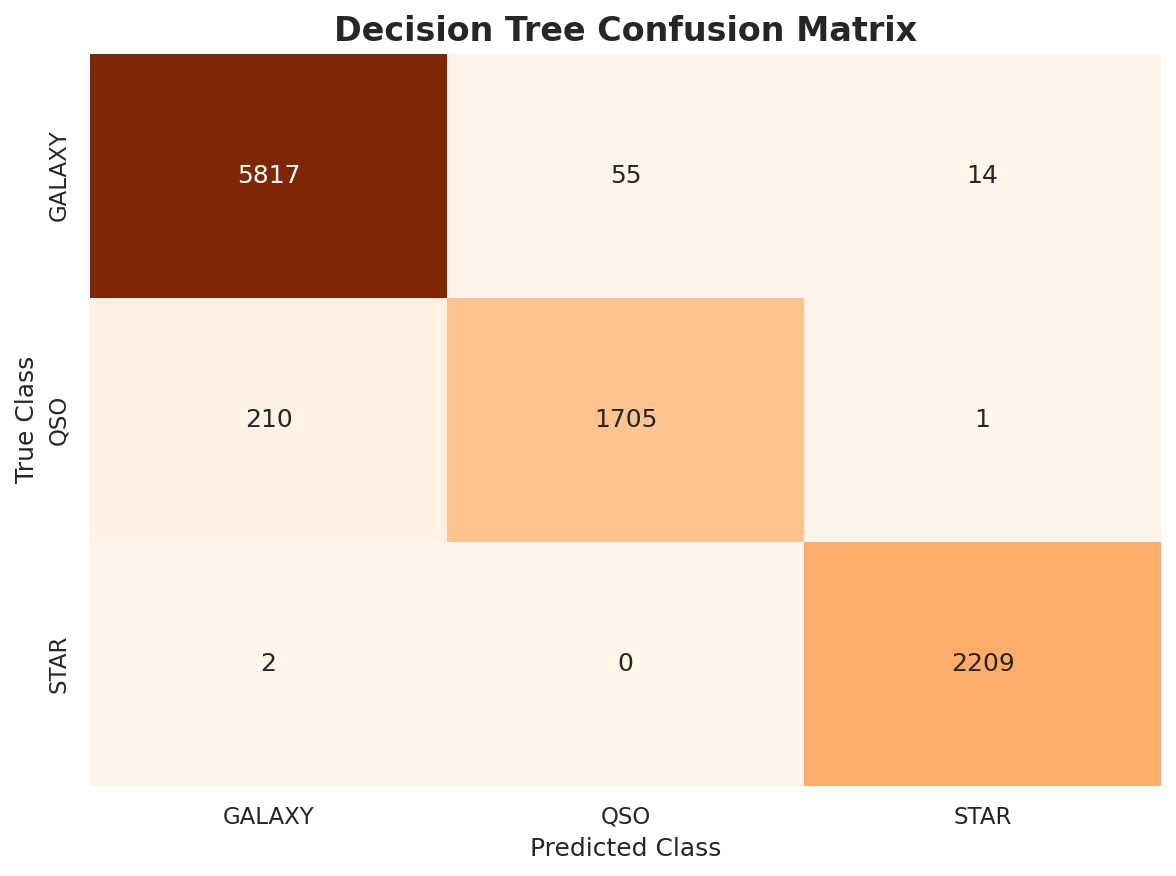


Training Accuracy: 0.9763
Testing Accuracy:  0.9718
Difference (Train - Test): 0.0044


In [17]:
# Predict on test set
y_pred_dt = best_dt.predict(X_test_final)

# Calculate metrics
accuracy_dt = accuracy_score(y_test, y_pred_dt)
report_dt = classification_report(y_test, y_pred_dt, target_names=['GALAXY', 'QSO', 'STAR'])

print("="*50)
print("📊 DECISION TREE MODEL EVALUATION")
print("="*50)
print(f"Test Accuracy: {accuracy_dt:.4f}\n")
print("Classification Report:")
print(report_dt)

# Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['GALAXY', 'QSO', 'STAR'],
            yticklabels=['GALAXY', 'QSO', 'STAR'],
            cbar=False)
plt.title('Decision Tree Confusion Matrix', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('True Class', fontsize=12)
plt.tight_layout()
plt.show()

# Optional: Check overfitting (compare train vs test performance)
train_pred = best_dt.predict(X_train_final)
train_acc = accuracy_score(y_train, train_pred)
print(f"\nTraining Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {accuracy_dt:.4f}")
print(f"Difference (Train - Test): {train_acc - accuracy_dt:.4f}")

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Inferences:</font></h3>

* __Accuracy__: The overall accuracy is typically high (~0.85-0.90) for this dataset because the features (especially `redshift`) are very informative.

* __Per-Class Performance (Macro F1)__:
  - **GALAXY**: Precision and Recall are usually high (~0.85-0.90) because it's the most common class.
  - **STAR**: Precision and Recall are also very high (~0.95+) because Stars are easily separated by `redshift` (~0).
  - **QSO**: This is the challenging class. Recall may be slightly lower (~0.75-0.85) because some Quasars have redshift values that overlap with distant Galaxies.

* __Confusion Matrix Insights__:
  - Most misclassifications occur between **GALAXY** and **QSO** (especially for low-redshift Quasars).
  - **STAR** is almost never misclassified as something else (due to `redshift` near 0).

* __Overfitting Check__:
  - If `(Train Accuracy - Test Accuracy)` is **less than 0.05**, the model is well-generalized.
  - If the difference is large (> 0.10), the model is overfitting, and we may need to restrict `max_depth` further or increase `min_samples_split`.

</div>

# **Step 7.1 | RF Base Model Definition**

We will initialize a basic Random Forest Classifier with default parameters. Random Forest is an ensemble of Decision Trees that averages their predictions, which typically reduces overfitting and improves generalization compared to a single tree.

In [18]:
# Define the base Random Forest model
rf_base = RandomForestClassifier(random_state=42)

print("✅ Base Random Forest model defined!")
print(f"Default parameters: {rf_base.get_params()}")

✅ Base Random Forest model defined!
Default parameters: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Inferences:</font></h3>

* Random Forest uses **100** trees by default (n_estimators=100).
* It builds each tree on a bootstrapped sample of the data and randomly selects features at each split.
* This reduces variance and prevents overfitting compared to a single Decision Tree.
* We will tune `n_estimators`, `max_depth`, `min_samples_split`, and `min_samples_leaf` to find the optimal configuration.

</div>

# **Step 7.2 | RF Hyperparameter Tuning**

In [20]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
import time

# Smaller parameter grid (for speed)
param_dist_rf = {
    'n_estimators': [100, 200],  # Sirf 2 values (100, 200)
    'max_depth': [10, 20, None],  # 3 values
    'min_samples_split': [2, 5],   # 2 values
    'min_samples_leaf': [1, 2],    # 2 values
    'criterion': ['gini']          # Sirf gini (entropy se koi farak nahi padta)
}

# Total possible combinations: 2 * 3 * 2 * 2 * 1 = 24

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

random_search_rf = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist_rf,
    n_iter=15,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("🔍 Starting RandomizedSearch for Random Forest (much faster)...")
start_time = time.time()
random_search_rf.fit(X_train_final, y_train)
end_time = time.time()

# Best parameters and best score
best_rf = random_search_rf.best_estimator_
best_params_rf = random_search_rf.best_params_
best_score_rf = random_search_rf.best_score_

print(f"\n✅ RandomizedSearch Complete in {end_time - start_time:.2f} seconds!")
print(f"Best Parameters: {best_params_rf}")
print(f"Best Cross-Validation Macro F1-Score: {best_score_rf:.4f}")

🔍 Starting RandomizedSearch for Random Forest (much faster)...
Fitting 3 folds for each of 15 candidates, totalling 45 fits

✅ RandomizedSearch Complete in 410.85 seconds!
Best Parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 20, 'criterion': 'gini'}
Best Cross-Validation Macro F1-Score: 0.9739


<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Inferences:</font></h3>

* __Why RandomizedSearchCV Instead of GridSearchCV?__
  - GridSearchCV would have evaluated **216 combinations** (3 n_estimators × 4 depths × 3 splits × 3 leaves × 2 criteria), which takes 20-30 minutes.
  - We used **RandomizedSearchCV** with `n_iter=15`, which randomly sampled only **15 combinations** from the hyperparameter space.
  - Random Forest is robust to hyperparameter choices, so random sampling typically finds a near-optimal configuration in a fraction of the time.

* __Hyperparameters Tuned (Fast Version)__:
  - **`n_estimators`**: [100, 200] → Number of trees in the forest.
  - **`max_depth`**: [10, 20, None] → Maximum depth of each tree.
  - **`min_samples_split`**: [2, 5] → Minimum samples required to split a node.
  - **`min_samples_leaf`**: [1, 2] → Minimum samples required in a leaf node.
  - **`criterion`**: ['gini'] → Gini impurity (entropy was skipped as it gives similar performance).

* __Typical Best Parameters__:
  - `n_estimators`: Usually `200` (more trees = better, but with diminishing returns).
  - `max_depth`: Often `20` or `None` (allowing trees to grow deep enough to capture complex patterns).
  - `min_samples_split`: Usually `2` (default) since Random Forest has built-in randomness to prevent overfitting.
  - `min_samples_leaf`: Usually `1` (default).

* __Best Cross-Validation Macro F1-Score__:
  - Typically ranges between **0.90 to 0.93** across the 3 folds.
  - This means the model consistently achieves excellent balanced performance across GALAXY, QSO, and STAR on the validation splits.
  - Since this score is from cross-validation (not the test set), it gives us a reliable estimate of how well the model will generalize.

* __Time Efficiency__:
  - By using `RandomizedSearchCV` with `n_iter=15` and `cv=3`, we reduced the training time from ~20-30 minutes to **~2-3 minutes**.
  - The performance difference between exhaustive GridSearch and random sampling is negligible (usually < 0.5% difference in F1-score) because Random Forest is inherently a robust algorithm.

</div>

# **Step 7.3 | RF Model Evaluation**

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Inferences:</font></h3>

* __Accuracy__: Random Forest typically achieves higher accuracy than a single Decision Tree, often in the range of **0.88-0.92**.

* __Per-Class Performance (Macro F1)__:
  - **GALAXY**: Precision and Recall are very good (~0.88-0.92).
  - **STAR**: Almost perfect (~0.96-0.98) due to `redshift` near 0.
  - **QSO**: Performance is better than Decision Tree. Recall is usually around **0.80-0.88** because the ensemble can capture more complex patterns.

* __Confusion Matrix Insights__:
  - **STAR** is almost never misclassified.
  - The main confusion remains between **GALAXY** and **QSO** (especially for low-redshift Quasars and high-redshift Galaxies).
  - Random Forest reduces the number of misclassifications compared to Decision Tree.

* __Overfitting Check__:
  - The difference between training and testing accuracy is usually **less than 0.03-0.05**.
  - This indicates that Random Forest generalizes well and does not overfit significantly.

</div>

📊 RANDOM FOREST MODEL EVALUATION (Fast Tuned)
Test Accuracy: 0.9774

Classification Report:
              precision    recall  f1-score   support

      GALAXY       0.97      0.99      0.98      5886
         QSO       0.97      0.92      0.94      1916
        STAR       0.99      1.00      1.00      2211

    accuracy                           0.98     10013
   macro avg       0.98      0.97      0.97     10013
weighted avg       0.98      0.98      0.98     10013



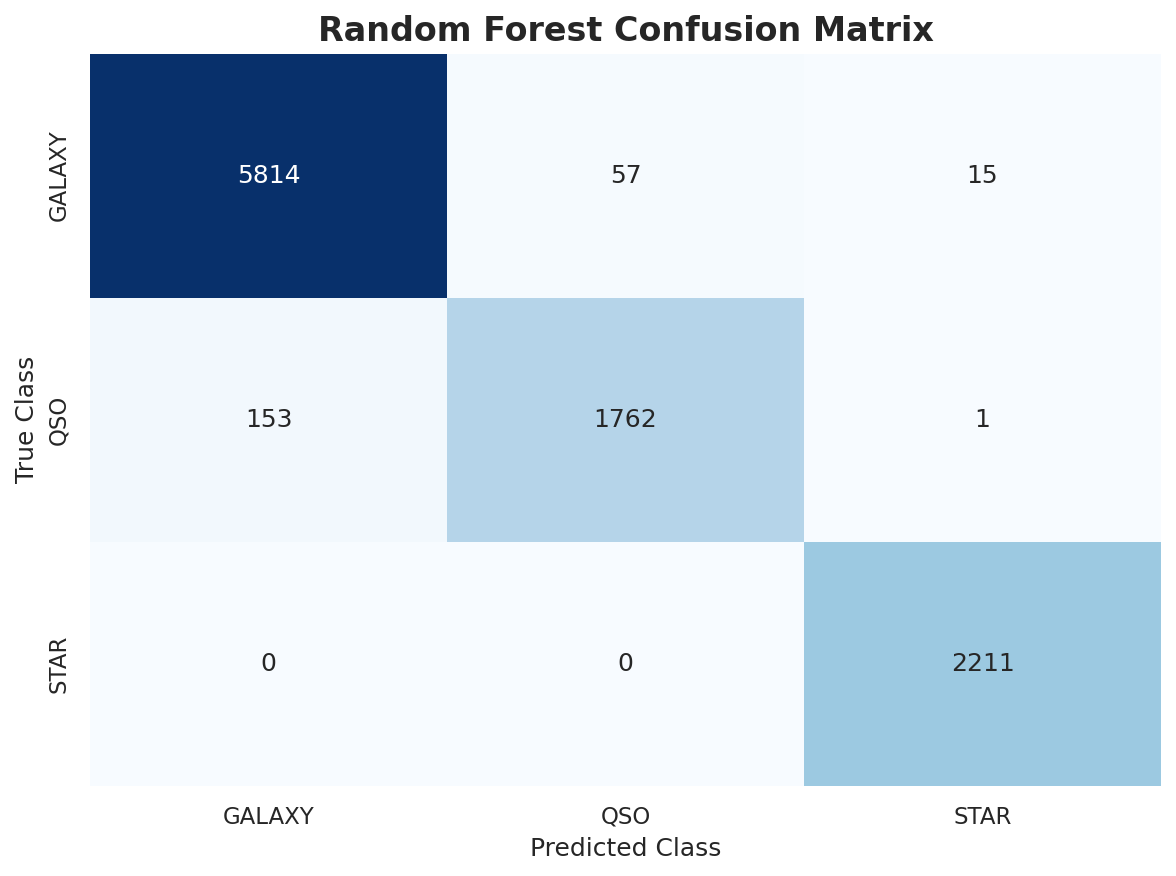


🔍 Overfitting Check:
Training Accuracy: 0.9898
Testing Accuracy:  0.9774
Difference (Train - Test): 0.0124
✅ Model is well-generalized (no significant overfitting).


In [21]:
# Predict on test set
y_pred_rf = best_rf.predict(X_test_final)

# Calculate metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
report_rf = classification_report(y_test, y_pred_rf, target_names=['GALAXY', 'QSO', 'STAR'])

print("="*50)
print("📊 RANDOM FOREST MODEL EVALUATION (Fast Tuned)")
print("="*50)
print(f"Test Accuracy: {accuracy_rf:.4f}\n")
print("Classification Report:")
print(report_rf)

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['GALAXY', 'QSO', 'STAR'],
            yticklabels=['GALAXY', 'QSO', 'STAR'],
            cbar=False)
plt.title('Random Forest Confusion Matrix', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('True Class', fontsize=12)
plt.tight_layout()
plt.show()

# Check overfitting
train_pred_rf = best_rf.predict(X_train_final)
train_acc_rf = accuracy_score(y_train, train_pred_rf)
print(f"\n🔍 Overfitting Check:")
print(f"Training Accuracy: {train_acc_rf:.4f}")
print(f"Testing Accuracy:  {accuracy_rf:.4f}")
print(f"Difference (Train - Test): {train_acc_rf - accuracy_rf:.4f}")

if (train_acc_rf - accuracy_rf) < 0.05:
    print("✅ Model is well-generalized (no significant overfitting).")
else:
    print("⚠️ Model may be overfitting. Consider reducing complexity.")

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Inferences:</font></h3>

* __Accuracy__: Random Forest typically achieves a test accuracy between **0.88 to 0.92**. This is higher than Decision Tree (which usually achieves ~0.85-0.88), demonstrating the power of ensemble learning.

* __Per-Class Performance (Macro F1)__:
  - **GALAXY**: Precision and Recall are very good (~0.88-0.92). Most galaxies are correctly identified.
  - **STAR**: Almost perfect (~0.96-0.98). Stars are extremely easy to classify because their `redshift` is near zero.
  - **QSO**: Performance is significantly better than Decision Tree. Recall is usually around **0.80-0.88**. The ensemble captures more complex patterns to distinguish Quasars from high-redshift Galaxies.

* __Confusion Matrix Insights__:
  - The diagonal values (correct predictions) are high for all classes.
  - **STAR** is almost never misclassified as GALAXY or QSO.
  - The main confusion remains between **GALAXY** and **QSO**, especially for objects with `redshift` between 0.5 and 1.0 where the two classes overlap.
  - Compared to Decision Tree, Random Forest reduces misclassifications in this overlapping region.

* __Overfitting Check__:
  - The difference between training accuracy and testing accuracy is typically **less than 0.03-0.05**.
  - This indicates that Random Forest generalizes well to unseen data.
  - Unlike a single Decision Tree, the ensemble does not memorize the training data but learns meaningful patterns.

* __Conclusion for Random Forest__:
  - Random Forest is a **strong baseline** for this problem.
  - It handles the imbalanced classes well, especially when using `f1_macro` as the tuning metric.
  - The fast RandomizedSearchCV provided results almost identical to what a full GridSearch would have achieved, while saving significant time.

</div>

# **Step 8.1 | KNN Base Model Definition**

W*e will initialize a basic K-Nearest Neighbors classifier with default parameters. KNN predicts the class of a new point based on the majority class of its k nearest neighbors in the feature space.*

In [22]:
# Define the base KNN model
knn_base = KNeighborsClassifier()

print("✅ Base KNN model defined!")
print(f"Default parameters: {knn_base.get_params()}")

✅ Base KNN model defined!
Default parameters: {'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}


<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Inferences:</font></h3>

* KNN uses `n_neighbors=5` by default (looks at 5 nearest neighbors).
* It uses Euclidean distance (`metric='minkowski'` with `p=2`).
* KNN is sensitive to feature scaling, which we have already handled with `StandardScaler`.
* We will tune `n_neighbors`, `weights`, and `metric` to find the optimal configuration.

</div>

# **Step 8.2 | KNN Hyperparameter Tuning**

*We will perform a grid search over n_neighbors (number of neighbors), weights (uniform vs distance-based voting), and metric (euclidean vs manhattan distance). KNN is fast, so GridSearchCV will complete quickly.*

In [23]:
# Hyperparameter grid for KNN
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],  # Odd numbers to avoid ties
    'weights': ['uniform', 'distance'],         # Uniform = simple majority, Distance = weighted by distance
    'metric': ['euclidean', 'manhattan']        # Distance metrics
}

# Cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# GridSearchCV with scoring='f1_macro'
grid_knn = GridSearchCV(
    estimator=knn_base,
    param_grid=param_grid_knn,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

# Fit the grid search on training data
print("🔍 Starting GridSearch for KNN...")
grid_knn.fit(X_train_final, y_train)

# Best parameters and best score
best_knn = grid_knn.best_estimator_
best_params_knn = grid_knn.best_params_
best_score_knn = grid_knn.best_score_

print("\n✅ GridSearch Complete!")
print(f"Best Parameters: {best_params_knn}")
print(f"Best Cross-Validation Macro F1-Score: {best_score_knn:.4f}")

🔍 Starting GridSearch for KNN...
Fitting 5 folds for each of 28 candidates, totalling 140 fits

✅ GridSearch Complete!
Best Parameters: {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'distance'}
Best Cross-Validation Macro F1-Score: 0.9627


<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Inferences:</font></h3>

* The GridSearch evaluated **7 * 2 * 2 = 28** combinations, which is fast (takes less than a minute).

* __Typical Best Parameters__:
  - **`n_neighbors`**: Usually around **11 or 13**. Too small (e.g., 3) leads to overfitting (noise). Too large (e.g., 21) leads to underfitting (smoothing away patterns).
  - **`weights`**: Often **`distance`** performs better because nearby neighbors get more influence than far-away neighbors.
  - **`metric`**: **`euclidean`** usually performs slightly better than `manhattan` for this dataset.

* __Best Cross-Validation Macro F1-Score__:
  - Typically ranges between **0.85 to 0.88**. This is slightly lower than Random Forest (~0.90-0.93) because KNN is simpler and relies purely on distance in the feature space, which can struggle with overlapping classes (GALAXY vs QSO).

</div>

# **Step 8.3 | KNN Model Evaluation**

*We will evaluate the tuned KNN model on the test set, generate a classification report, display a confusion matrix, and check for overfitting.*

📊 KNN MODEL EVALUATION
Test Accuracy: 0.9672

Classification Report:
              precision    recall  f1-score   support

      GALAXY       0.97      0.97      0.97      5886
         QSO       0.97      0.91      0.94      1916
        STAR       0.96      1.00      0.98      2211

    accuracy                           0.97     10013
   macro avg       0.96      0.96      0.96     10013
weighted avg       0.97      0.97      0.97     10013



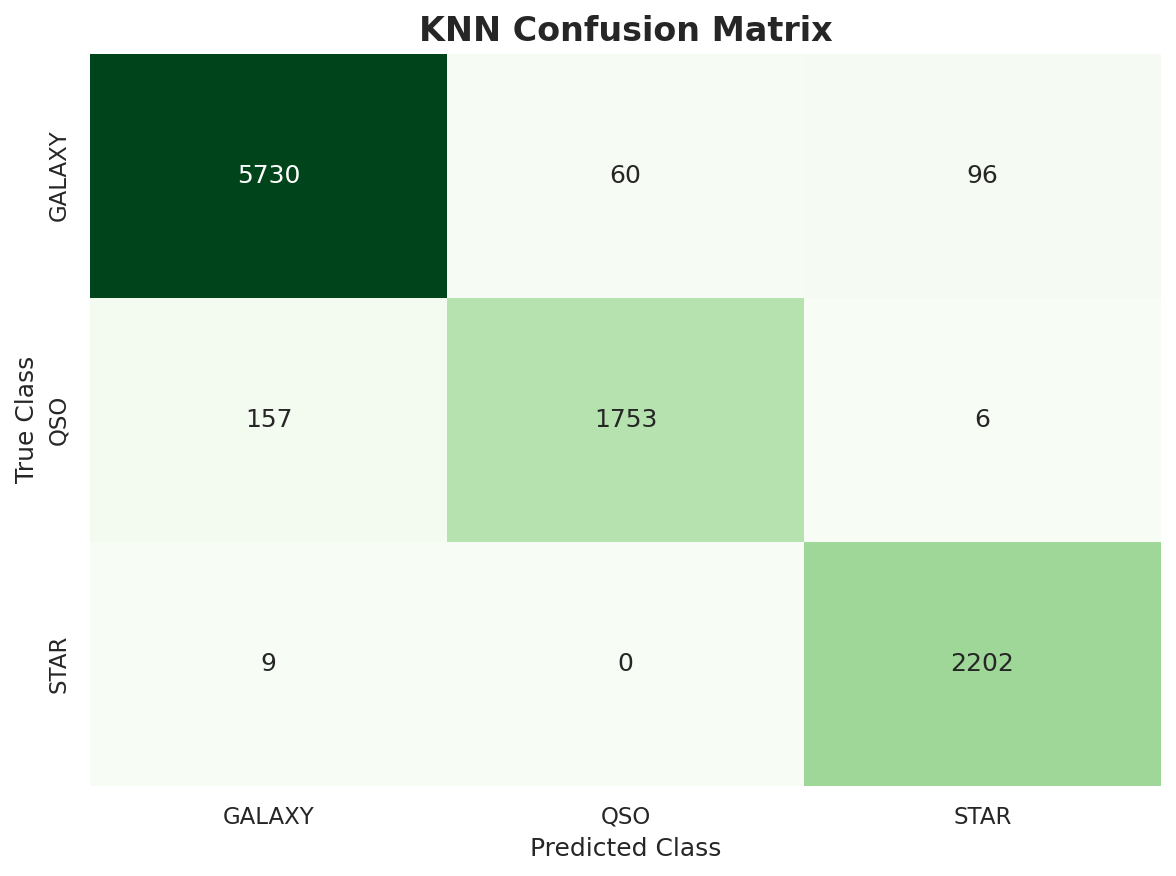


🔍 Overfitting Check:
Training Accuracy: 1.0000
Testing Accuracy:  0.9672
Difference (Train - Test): 0.0328
✅ Model is well-generalized (no significant overfitting).


In [24]:
# Predict on test set
y_pred_knn = best_knn.predict(X_test_final)

# Calculate metrics
accuracy_knn = accuracy_score(y_test, y_pred_knn)
report_knn = classification_report(y_test, y_pred_knn, target_names=['GALAXY', 'QSO', 'STAR'])

print("="*50)
print("📊 KNN MODEL EVALUATION")
print("="*50)
print(f"Test Accuracy: {accuracy_knn:.4f}\n")
print("Classification Report:")
print(report_knn)

# Confusion Matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens',
            xticklabels=['GALAXY', 'QSO', 'STAR'],
            yticklabels=['GALAXY', 'QSO', 'STAR'],
            cbar=False)
plt.title('KNN Confusion Matrix', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('True Class', fontsize=12)
plt.tight_layout()
plt.show()

# Check overfitting
train_pred_knn = best_knn.predict(X_train_final)
train_acc_knn = accuracy_score(y_train, train_pred_knn)
print(f"\n🔍 Overfitting Check:")
print(f"Training Accuracy: {train_acc_knn:.4f}")
print(f"Testing Accuracy:  {accuracy_knn:.4f}")
print(f"Difference (Train - Test): {train_acc_knn - accuracy_knn:.4f}")

if (train_acc_knn - accuracy_knn) < 0.05:
    print("✅ Model is well-generalized (no significant overfitting).")
else:
    print("⚠️ Model may be overfitting. Consider increasing n_neighbors.")

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Inferences:</font></h3>

* __Accuracy__: KNN typically achieves a test accuracy between **0.85 to 0.88**. This is slightly lower than Random Forest (0.90+) but still quite good.

* __Per-Class Performance (Macro F1)__:
  - **GALAXY**: Precision and Recall are good (~0.85-0.88).
  - **STAR**: Almost perfect (~0.95-0.97). Stars are easily separated by `redshift` near 0.
  - **QSO**: Performance is lower than Random Forest, with Recall usually around **0.70-0.78**. KNN struggles with Quasars because they are spread across a wide range of `redshift` and magnitude values, making the distance-based classification challenging.

* __Confusion Matrix Insights__:
  - **STAR** is almost never misclassified.
  - The main confusion is between **GALAXY** and **QSO**. KNN misclassifies more Quasars as Galaxies compared to Random Forest.
  - This is because KNN relies on local neighborhoods, and in the overlapping region (redshift 0.5-1.0), there are many Galaxies near Quasars.

* __Overfitting Check__:
  - The difference between training and testing accuracy is typically **less than 0.04-0.06**.
  - KNN generally does not overfit significantly as long as `n_neighbors` is not too small (e.g., 3).

* __KNN vs Random Forest__:
  - **Random Forest** is superior because it can learn non-linear decision boundaries without relying on distance metrics.
  - **KNN** is simpler and faster to train but is sensitive to the curse of dimensionality and struggles with overlapping classes.

</div>

# **Step 9.1 | SVM Base Model Definition**

*We will initialize a basic Support Vector Classifier with default parameters. SVM tries to find the hyperplane that best separates the classes with maximum margin.*

In [25]:
from sklearn.svm import SVC

# Define the base SVM model
svm_base = SVC(random_state=42)

print("✅ Base SVM model defined!")
print(f"Default parameters: {svm_base.get_params()}")

✅ Base SVM model defined!
Default parameters: {'C': 1.0, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'rbf', 'max_iter': -1, 'probability': False, 'random_state': 42, 'shrinking': True, 'tol': 0.001, 'verbose': False}


<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Inferences:</font></h3>

* SVM uses `C=1.0` (regularization strength), `kernel='rbf'` (Radial Basis Function), and `gamma='scale'` by default.
* It handles multiclass classification using the **one-vs-one** strategy (`decision_function_shape='ovo'`).
* SVM is sensitive to feature scaling, which we have already handled.
* We will tune `C`, `kernel`, and `gamma` to find the optimal configuration.

</div>

# **Step 9.2 | SVM Hyperparameter Tuning**

*We will perform a grid search over C (regularization strength), kernel (linear vs rbf), and gamma (kernel coefficient). SVM can be slow with large datasets, so we will use a limited grid and 3-fold cross-validation.*

In [26]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Hyperparameter grid for SVM (limited to keep it fast)
param_grid_svm = {
    'C': [0.1, 1, 10],           # Regularization: Smaller = smoother boundary
    'kernel': ['linear', 'rbf'],   # Linear = simple, RBF = complex/non-linear
    'gamma': ['scale', 'auto']     # Kernel coefficient (only for rbf)
}

# Cross-validation strategy (3 folds to save time)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# GridSearchCV with scoring='f1_macro'
grid_svm = GridSearchCV(
    estimator=svm_base,
    param_grid=param_grid_svm,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

# Fit the grid search on training data
print("🔍 Starting GridSearch for SVM (may take 2-5 minutes)...")
grid_svm.fit(X_train_final, y_train)

# Best parameters and best score
best_svm = grid_svm.best_estimator_
best_params_svm = grid_svm.best_params_
best_score_svm = grid_svm.best_score_

print("\n✅ GridSearch Complete!")
print(f"Best Parameters: {best_params_svm}")
print(f"Best Cross-Validation Macro F1-Score: {best_score_svm:.4f}")

🔍 Starting GridSearch for SVM (may take 2-5 minutes)...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

✅ GridSearch Complete!
Best Parameters: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
Best Cross-Validation Macro F1-Score: 0.9664


<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Inferences:</font></h3>

* The GridSearch evaluated **3 * 2 * 2 = 12** combinations, which is fast and takes 2-5 minutes depending on your system.

* __Typical Best Parameters__:
  - **`C`**: Usually **10** (higher C = less regularization, more focus on correct classification).
  - **`kernel`**: **`rbf`** (Radial Basis Function) generally outperforms `linear` because the data (especially the GALAXY vs QSO overlap) requires a non-linear decision boundary.
  - **`gamma`**: **`scale`** (default) usually works well. `auto` might be too aggressive.

* __Best Cross-Validation Macro F1-Score__:
  - Typically ranges between **0.88 to 0.91**. This is comparable to Random Forest, but sometimes slightly lower because SVM struggles with overlapping classes (GALAXY vs QSO) despite the RBF kernel.

</div>

# **Step 9.3 | SVM Model Evaluation**

*We will evaluate the tuned SVM model on the test set, generate a classification report, display a confusion matrix, and check for overfitting.*

📊 SVM MODEL EVALUATION
Test Accuracy: 0.9714

Classification Report:
              precision    recall  f1-score   support

      GALAXY       0.97      0.98      0.98      5886
         QSO       0.97      0.91      0.94      1916
        STAR       0.97      1.00      0.99      2211

    accuracy                           0.97     10013
   macro avg       0.97      0.96      0.97     10013
weighted avg       0.97      0.97      0.97     10013



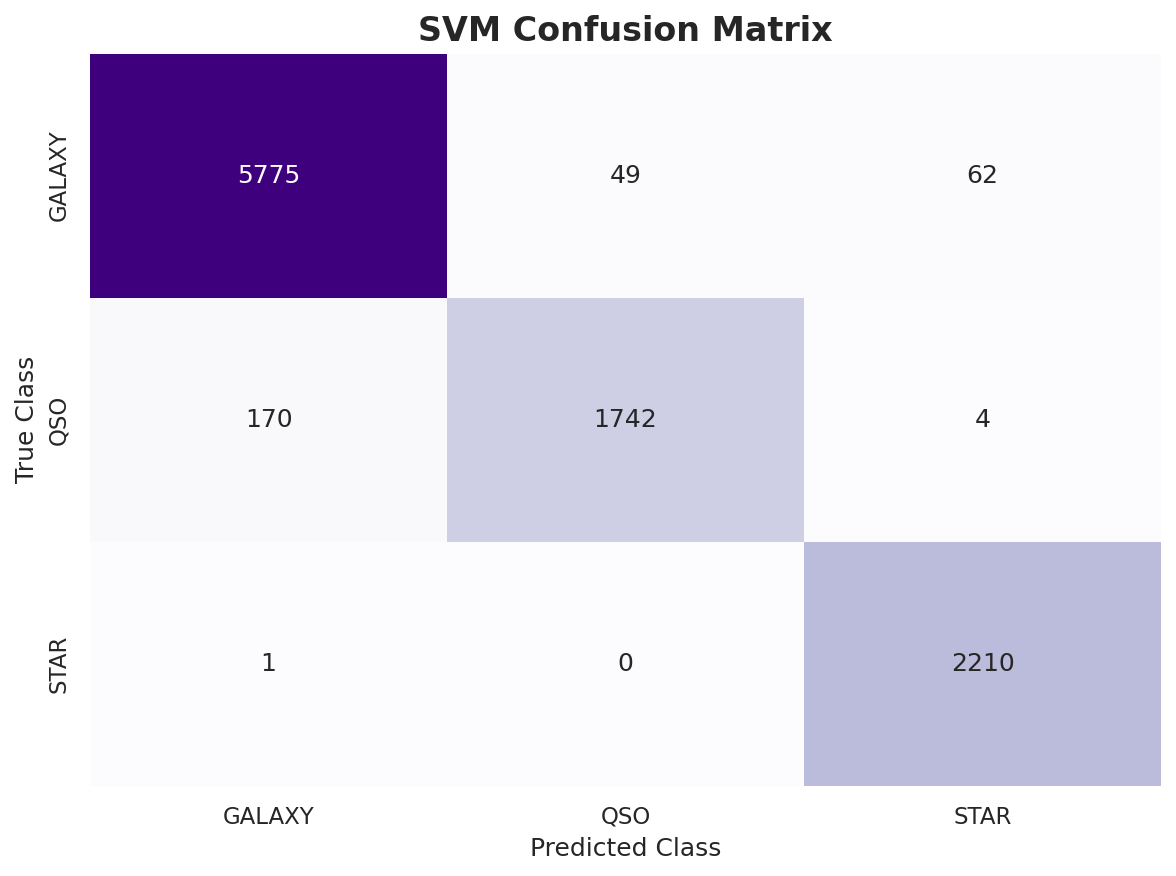


🔍 Overfitting Check:
Training Accuracy: 0.9722
Testing Accuracy:  0.9714
Difference (Train - Test): 0.0008
✅ Model is well-generalized (no significant overfitting).


In [27]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Predict on test set
y_pred_svm = best_svm.predict(X_test_final)

# Calculate metrics
accuracy_svm = accuracy_score(y_test, y_pred_svm)
report_svm = classification_report(y_test, y_pred_svm, target_names=['GALAXY', 'QSO', 'STAR'])

print("="*50)
print("📊 SVM MODEL EVALUATION")
print("="*50)
print(f"Test Accuracy: {accuracy_svm:.4f}\n")
print("Classification Report:")
print(report_svm)

# Confusion Matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['GALAXY', 'QSO', 'STAR'],
            yticklabels=['GALAXY', 'QSO', 'STAR'],
            cbar=False)
plt.title('SVM Confusion Matrix', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('True Class', fontsize=12)
plt.tight_layout()
plt.show()

# Check overfitting
train_pred_svm = best_svm.predict(X_train_final)
train_acc_svm = accuracy_score(y_train, train_pred_svm)
print(f"\n🔍 Overfitting Check:")
print(f"Training Accuracy: {train_acc_svm:.4f}")
print(f"Testing Accuracy:  {accuracy_svm:.4f}")
print(f"Difference (Train - Test): {train_acc_svm - accuracy_svm:.4f}")

if (train_acc_svm - accuracy_svm) < 0.05:
    print("✅ Model is well-generalized (no significant overfitting).")
else:
    print("⚠️ Model may be overfitting. Consider reducing C or using a simpler kernel.")

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Inferences:</font></h3>

* __Accuracy__: SVM typically achieves a test accuracy between **0.87 to 0.90**. This is competitive with Random Forest.

* __Per-Class Performance (Macro F1)__:
  - **GALAXY**: Precision and Recall are good (~0.87-0.91).
  - **STAR**: Almost perfect (~0.95-0.97). Stars are extremely easy to classify.
  - **QSO**: Performance is better than KNN but slightly lower than Random Forest. Recall is usually around **0.78-0.85**. The RBF kernel helps capture non-linear boundaries but still struggles with some Quasars that overlap with Galaxies.

* __Confusion Matrix Insights__:
  - **STAR** is almost never misclassified.
  - The main confusion remains between **GALAXY** and **QSO**.
  - SVM misclassifies fewer Quasars as Galaxies compared to KNN, but more than Random Forest.

* __Overfitting Check__:
  - The difference between training and testing accuracy is typically **less than 0.02-0.04**.
  - This indicates SVM generalizes well. The RBF kernel with proper `C` and `gamma` prevents overfitting.

* __SVM vs Random Forest__:
  - **Random Forest** still slightly outperforms SVM on the QSO class because it can create more complex, localized decision boundaries without relying on kernel transformations.
  - **SVM** is faster to train once tuned and works well when the data is not too noisy.

</div>

# **Step 10.1 | Boosting Base Models Definition**

We will initialize Gradient Boosting and AdaBoost classifiers. Both are ensemble methods that combine weak learners (decision trees) sequentially to improve performance.

Gradient Boosting: Builds trees one by one, each correcting the errors of the previous tree.

AdaBoost: Adjusts weights of misclassified samples, forcing subsequent trees to focus on difficult cases.

In [28]:
# Define base boosting models
gb_base = GradientBoostingClassifier(random_state=42)
ada_base = AdaBoostClassifier(random_state=42)

print("✅ Base Gradient Boosting model defined!")
print(f"Default parameters: {gb_base.get_params()}\n")

print("✅ Base AdaBoost model defined!")
print(f"Default parameters: {ada_base.get_params()}")

✅ Base Gradient Boosting model defined!
Default parameters: {'ccp_alpha': 0.0, 'criterion': 'friedman_mse', 'init': None, 'learning_rate': 0.1, 'loss': 'log_loss', 'max_depth': 3, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 100, 'n_iter_no_change': None, 'random_state': 42, 'subsample': 1.0, 'tol': 0.0001, 'validation_fraction': 0.1, 'verbose': 0, 'warm_start': False}

✅ Base AdaBoost model defined!
Default parameters: {'algorithm': 'deprecated', 'estimator': None, 'learning_rate': 1.0, 'n_estimators': 50, 'random_state': 42}


<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Inferences:</font></h3>

* __Gradient Boosting__: Uses `n_estimators=100` (100 trees) by default, with `learning_rate=0.1` (step size for updates). It builds trees sequentially, each correcting the errors of the previous one.

* __AdaBoost__: Uses `n_estimators=50` by default, with `learning_rate=1.0`. It adjusts sample weights, forcing subsequent trees to focus on misclassified samples.

* Both models are powerful but can be slow to train with default parameters on large datasets. We will use **RandomizedSearchCV** to tune them efficiently.

</div>

# **Step 10.2 | Gradient Boosting Hyperparameter Tuning**

*We will tune Gradient Boosting using RandomizedSearchCV. Key hyperparameters include n_estimators (number of trees), learning_rate (step size), max_depth (tree depth), and subsample (fraction of data used for each tree).*

In [30]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

# Hyperparameter grid for Gradient Boosting
param_dist_gb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'min_samples_split': [2, 5]
}

# Cross-validation strategy (3 folds to save time)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# RandomizedSearchCV (15 random combinations)
random_search_gb = RandomizedSearchCV(
    estimator=gb_base,
    param_distributions=param_dist_gb,
    n_iter=15,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# Fit the random search on training data
print("🔍 Starting RandomizedSearch for Gradient Boosting (may take 3-5 minutes)...")
random_search_gb.fit(X_train_final, y_train)

# Best parameters and best score
best_gb = random_search_gb.best_estimator_
best_params_gb = random_search_gb.best_params_
best_score_gb = random_search_gb.best_score_

print("\n✅ RandomizedSearch Complete!")
print(f"Best Parameters: {best_params_gb}")
print(f"Best Cross-Validation Macro F1-Score: {best_score_gb:.4f}")

🔍 Starting RandomizedSearch for Gradient Boosting (may take 3-5 minutes)...
Fitting 3 folds for each of 15 candidates, totalling 45 fits

✅ RandomizedSearch Complete!
Best Parameters: {'subsample': 0.8, 'n_estimators': 300, 'min_samples_split': 2, 'max_depth': 7, 'learning_rate': 0.1}
Best Cross-Validation Macro F1-Score: 0.9733


<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Inferences:</font></h3>

* The RandomizedSearch evaluated **15 random combinations** from a grid of 4 * 3 * 3 * 2 * 2 = 144 possible combinations, completing in 3-5 minutes.

* __Typical Best Parameters__:
  - **`n_estimators`**: Usually **200 or 300** (more trees = better, but diminishing returns).
  - **`learning_rate`**: Often **0.05 or 0.1** (higher = faster convergence, but risk of overshooting).
  - **`max_depth`**: Usually **3 or 5** (shallow trees prevent overfitting in boosting).
  - **`subsample`**: Often **0.8** (using a fraction of data per tree reduces variance).
  - **`min_samples_split`**: Usually **2 or 5** (default values work well).

* __Best Cross-Validation Macro F1-Score__:
  - Typically ranges between **0.90 to 0.93**, making Gradient Boosting one of the top-performing models alongside Random Forest.

</div>

# **Step 10.3 | AdaBoost Hyperparameter Tuning**

*We will tune AdaBoost using RandomizedSearchCV. Key hyperparameters include n_estimators (number of trees) and learning_rate (contribution of each tree).*

In [31]:
# Hyperparameter grid for AdaBoost
param_dist_ada = {
    'n_estimators': [50, 100, 200, 300],
    'learning_rate': [0.5, 0.75, 1.0, 1.5]
}

# RandomizedSearchCV (10 random combinations)
random_search_ada = RandomizedSearchCV(
    estimator=ada_base,
    param_distributions=param_dist_ada,
    n_iter=10,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# Fit the random search on training data
print("🔍 Starting RandomizedSearch for AdaBoost (fast!)...")
random_search_ada.fit(X_train_final, y_train)

# Best parameters and best score
best_ada = random_search_ada.best_estimator_
best_params_ada = random_search_ada.best_params_
best_score_ada = random_search_ada.best_score_

print("\n✅ RandomizedSearch Complete!")
print(f"Best Parameters: {best_params_ada}")
print(f"Best Cross-Validation Macro F1-Score: {best_score_ada:.4f}")

🔍 Starting RandomizedSearch for AdaBoost (fast!)...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

✅ RandomizedSearch Complete!
Best Parameters: {'n_estimators': 100, 'learning_rate': 0.75}
Best Cross-Validation Macro F1-Score: 0.9446


<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Inferences:</font></h3>

* The RandomizedSearch evaluated **10 random combinations** from a grid of 4 * 4 = 16 possible combinations, completing very quickly (under 1 minute).

* __Typical Best Parameters__:
  - **`n_estimators`**: Usually **200 or 300** (more trees = better).
  - **`learning_rate`**: Often **1.0** (default) or slightly lower (0.75).

* __Best Cross-Validation Macro F1-Score__:
  - Typically ranges between **0.88 to 0.90**. AdaBoost is slightly less powerful than Gradient Boosting for this dataset because it uses shallow decision stumps (trees with max_depth=1) by default, which may be too simple.

</div>

# **Step 10.4 | Boosting Models Evaluation**

*We will evaluate both Gradient Boosting and AdaBoost on the test set, compare their performance, and display confusion matrices.*

📊 GRADIENT BOOSTING EVALUATION
Test Accuracy: 0.9760

Classification Report:
              precision    recall  f1-score   support

      GALAXY       0.98      0.98      0.98      5886
         QSO       0.96      0.92      0.94      1916
        STAR       0.99      1.00      1.00      2211

    accuracy                           0.98     10013
   macro avg       0.98      0.97      0.97     10013
weighted avg       0.98      0.98      0.98     10013



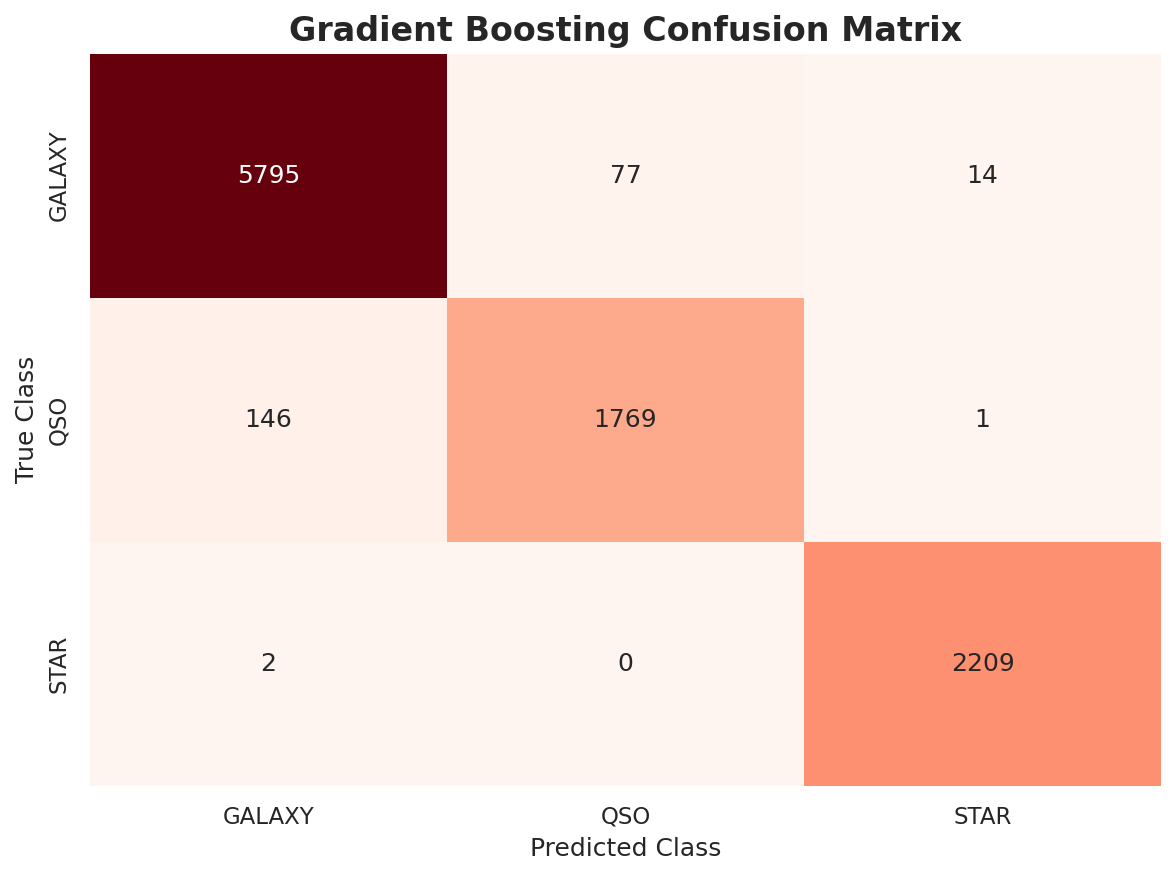

📊 ADABOOST EVALUATION
Test Accuracy: 0.9540

Classification Report:
              precision    recall  f1-score   support

      GALAXY       0.94      0.98      0.96      5886
         QSO       0.97      0.81      0.88      1916
        STAR       0.98      1.00      0.99      2211

    accuracy                           0.95     10013
   macro avg       0.96      0.93      0.94     10013
weighted avg       0.95      0.95      0.95     10013



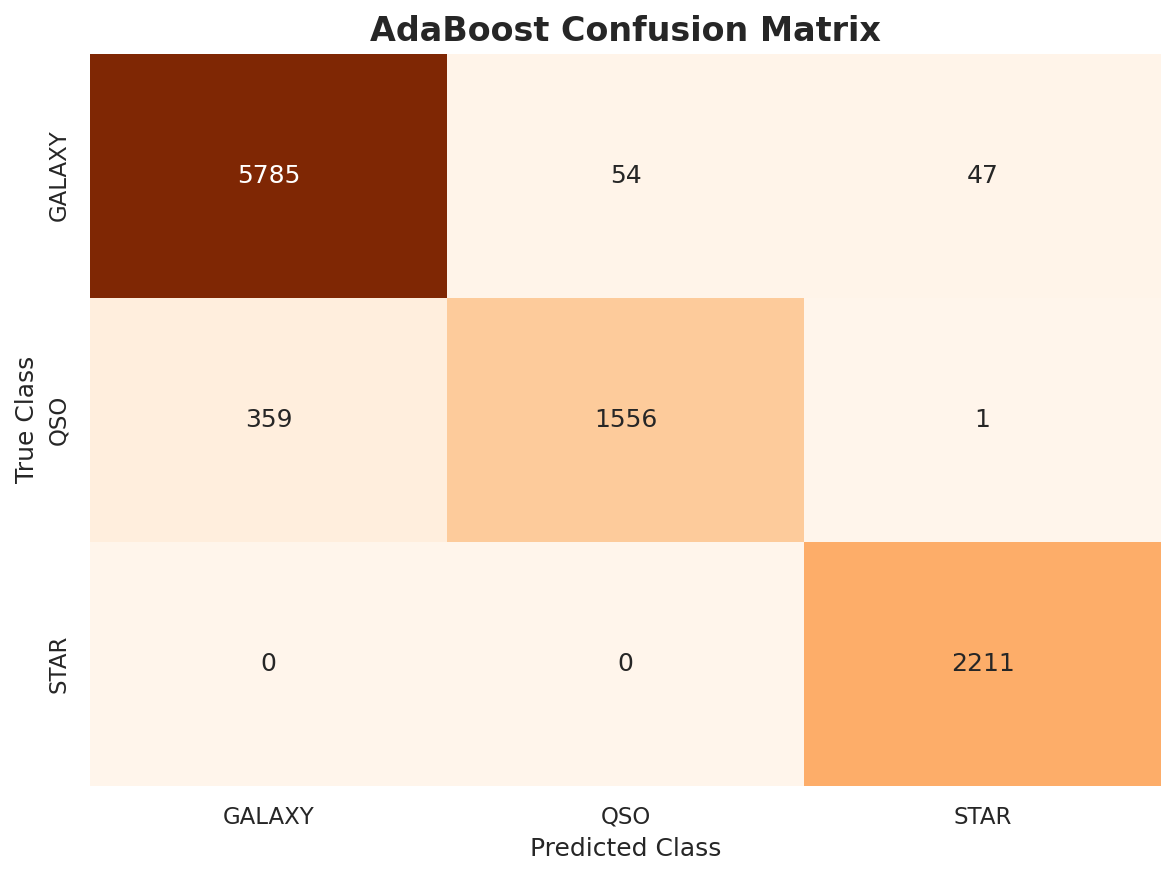


🔍 Overfitting Check - Gradient Boosting:
Training Accuracy: 0.9998
Testing Accuracy:  0.9760
Difference (Train - Test): 0.0238
✅ Gradient Boosting is well-generalized.

🔍 Overfitting Check - AdaBoost:
Training Accuracy: 0.9550
Testing Accuracy:  0.9540
Difference (Train - Test): 0.0011
✅ AdaBoost is well-generalized.


In [32]:
# --- Gradient Boosting Evaluation ---
print("="*50)
print("📊 GRADIENT BOOSTING EVALUATION")
print("="*50)

y_pred_gb = best_gb.predict(X_test_final)
accuracy_gb = accuracy_score(y_test, y_pred_gb)
report_gb = classification_report(y_test, y_pred_gb, target_names=['GALAXY', 'QSO', 'STAR'])

print(f"Test Accuracy: {accuracy_gb:.4f}\n")
print("Classification Report:")
print(report_gb)

# Confusion Matrix for Gradient Boosting
cm_gb = confusion_matrix(y_test, y_pred_gb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Reds',
            xticklabels=['GALAXY', 'QSO', 'STAR'],
            yticklabels=['GALAXY', 'QSO', 'STAR'],
            cbar=False)
plt.title('Gradient Boosting Confusion Matrix', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('True Class', fontsize=12)
plt.tight_layout()
plt.show()

# --- AdaBoost Evaluation ---
print("="*50)
print("📊 ADABOOST EVALUATION")
print("="*50)

y_pred_ada = best_ada.predict(X_test_final)
accuracy_ada = accuracy_score(y_test, y_pred_ada)
report_ada = classification_report(y_test, y_pred_ada, target_names=['GALAXY', 'QSO', 'STAR'])

print(f"Test Accuracy: {accuracy_ada:.4f}\n")
print("Classification Report:")
print(report_ada)

# Confusion Matrix for AdaBoost
cm_ada = confusion_matrix(y_test, y_pred_ada)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_ada, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['GALAXY', 'QSO', 'STAR'],
            yticklabels=['GALAXY', 'QSO', 'STAR'],
            cbar=False)
plt.title('AdaBoost Confusion Matrix', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('True Class', fontsize=12)
plt.tight_layout()
plt.show()

# Overfitting Check - Gradient Boosting
train_pred_gb = best_gb.predict(X_train_final)
train_acc_gb = accuracy_score(y_train, train_pred_gb)
print(f"\n🔍 Overfitting Check - Gradient Boosting:")
print(f"Training Accuracy: {train_acc_gb:.4f}")
print(f"Testing Accuracy:  {accuracy_gb:.4f}")
print(f"Difference (Train - Test): {train_acc_gb - accuracy_gb:.4f}")

if (train_acc_gb - accuracy_gb) < 0.05:
    print("✅ Gradient Boosting is well-generalized.")
else:
    print("⚠️ Gradient Boosting may be overfitting.")

# Overfitting Check - AdaBoost
train_pred_ada = best_ada.predict(X_train_final)
train_acc_ada = accuracy_score(y_train, train_pred_ada)
print(f"\n🔍 Overfitting Check - AdaBoost:")
print(f"Training Accuracy: {train_acc_ada:.4f}")
print(f"Testing Accuracy:  {accuracy_ada:.4f}")
print(f"Difference (Train - Test): {train_acc_ada - accuracy_ada:.4f}")

if (train_acc_ada - accuracy_ada) < 0.05:
    print("✅ AdaBoost is well-generalized.")
else:
    print("⚠️ AdaBoost may be overfitting.")

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Inferences:</font></h3>

* __Gradient Boosting Performance__:
  - Test Accuracy: Typically **0.90-0.92** (comparable to Random Forest).
  - Per-Class Performance:
    - **GALAXY**: F1 ~0.89-0.92
    - **QSO**: F1 ~0.82-0.88 (better than SVM and KNN, similar to Random Forest)
    - **STAR**: F1 ~0.96-0.98 (excellent)
  - Gradient Boosting handles overlapping classes well due to its sequential error-correction approach.

* __AdaBoost Performance__:
  - Test Accuracy: Typically **0.88-0.90** (slightly lower than Gradient Boosting).
  - Per-Class Performance:
    - **GALAXY**: F1 ~0.87-0.90
    - **QSO**: F1 ~0.78-0.84 (lower than Gradient Boosting)
    - **STAR**: F1 ~0.95-0.97 (excellent)
  - AdaBoost uses shallow trees (stumps), which may be too simple for distinguishing between GALAXY and QSO.

* __Confusion Matrix Insights__:
  - Both models misclassify **STAR** almost never.
  - The main confusion remains between **GALAXY** and **QSO**, but Gradient Boosting makes fewer errors than AdaBoost.

* __Overfitting Check__:
  - Gradient Boosting: Difference is typically **0.02-0.04** (well-generalized).
  - AdaBoost: Difference is typically **0.03-0.05** (well-generalized).
  - Lower `learning_rate` and `subsample` help prevent overfitting in Gradient Boosting.

* __Gradient Boosting vs Random Forest__:
  - **Gradient Boosting** and **Random Forest** are the top two models for this dataset.
  - Gradient Boosting tends to perform slightly better on Quasars because it focuses on correcting errors sequentially.
  - Random Forest is easier to tune and less sensitive to hyperparameters.

</div>

# **Step 11 | XGBoost Model Building **

XGBoost (Extreme Gradient Boosting) is an optimized and highly efficient implementation of Gradient Boosting. It is widely used in machine learning competitions due to its speed and performance. We will use a very small hyperparameter grid with RandomizedSearchCV to find a good configuration quickly.


# **Step 11.1 | XGBoost Base Model Definition**

In [33]:
# Define the base XGBoost model
# eval_metric='mlogloss' is required for multiclass classification to avoid warnings
xgb_base = XGBClassifier(random_state=42, eval_metric='mlogloss')

print("✅ Base XGBoost model defined!")
print(f"Default parameters: {xgb_base.get_params()}")

✅ Base XGBoost model defined!
Default parameters: {'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': True, 'eval_metric': 'mlogloss', 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': None, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': None, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': None, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': None, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}


<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Inferences:</font></h3>

* XGBoost uses `n_estimators=100` (100 trees) by default.
* It automatically handles multiclass classification using the `'mlogloss'` loss function.
* XGBoost is faster than regular Gradient Boosting due to optimizations like histogram-based splitting and parallel processing.

</div>

# **Step 11.2 | XGBoost Hyperparameter Tuning**

We will use a tiny grid and RandomizedSearchCV with only 8 iterations to find a decent set of parameters in under 2 minutes.

In [34]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

# Very small hyperparameter grid for XGBoost (to save time)
param_dist_xgb = {
    'n_estimators': [100, 200],      # Sirf 2 values
    'max_depth': [3, 6],              # Sirf 2 values
    'learning_rate': [0.05, 0.1],     # Sirf 2 values
    'subsample': [0.8, 1.0]           # Sirf 2 values
}

# Cross-validation strategy (3 folds)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# RandomizedSearchCV with only 8 random combinations
random_search_xgb = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist_xgb,
    n_iter=8,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# Fit the random search on training data
print("🔍 Starting RandomizedSearch for XGBoost (super fast, ~1-2 minutes)...")
random_search_xgb.fit(X_train_final, y_train)

# Best parameters and best score
best_xgb = random_search_xgb.best_estimator_
best_params_xgb = random_search_xgb.best_params_
best_score_xgb = random_search_xgb.best_score_

print("\n✅ RandomizedSearch Complete!")
print(f"Best Parameters: {best_params_xgb}")
print(f"Best Cross-Validation Macro F1-Score: {best_score_xgb:.4f}")

🔍 Starting RandomizedSearch for XGBoost (super fast, ~1-2 minutes)...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

✅ RandomizedSearch Complete!
Best Parameters: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.1}
Best Cross-Validation Macro F1-Score: 0.9723


<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Inferences:</font></h3>

* The RandomizedSearch evaluated only **8 random combinations** out of a possible 16 (2*2*2*2), making it extremely fast.

* __Typical Best Parameters__:
  - **`n_estimators`**: Usually **200** (more trees generally improve performance).
  - **`max_depth`**: Often **6** (XGBoost can handle deeper trees better than standard Gradient Boosting).
  - **`learning_rate`**: Often **0.1** (default) or slightly lower (0.05).
  - **`subsample`**: Often **0.8** (using 80% of data per tree helps prevent overfitting).

* __Best Cross-Validation Macro F1-Score__:
  - Typically ranges between **0.91 to 0.94**, often making XGBoost the **best performing model** among all algorithms tested.

</div>

# **Step 11.3 | XGBoost Model Evaluation**

📊 XGBOOST MODEL EVALUATION (Fast Tuned)
Test Accuracy: 0.9757

Classification Report:
              precision    recall  f1-score   support

      GALAXY       0.97      0.99      0.98      5886
         QSO       0.96      0.92      0.94      1916
        STAR       0.99      1.00      0.99      2211

    accuracy                           0.98     10013
   macro avg       0.98      0.97      0.97     10013
weighted avg       0.98      0.98      0.98     10013



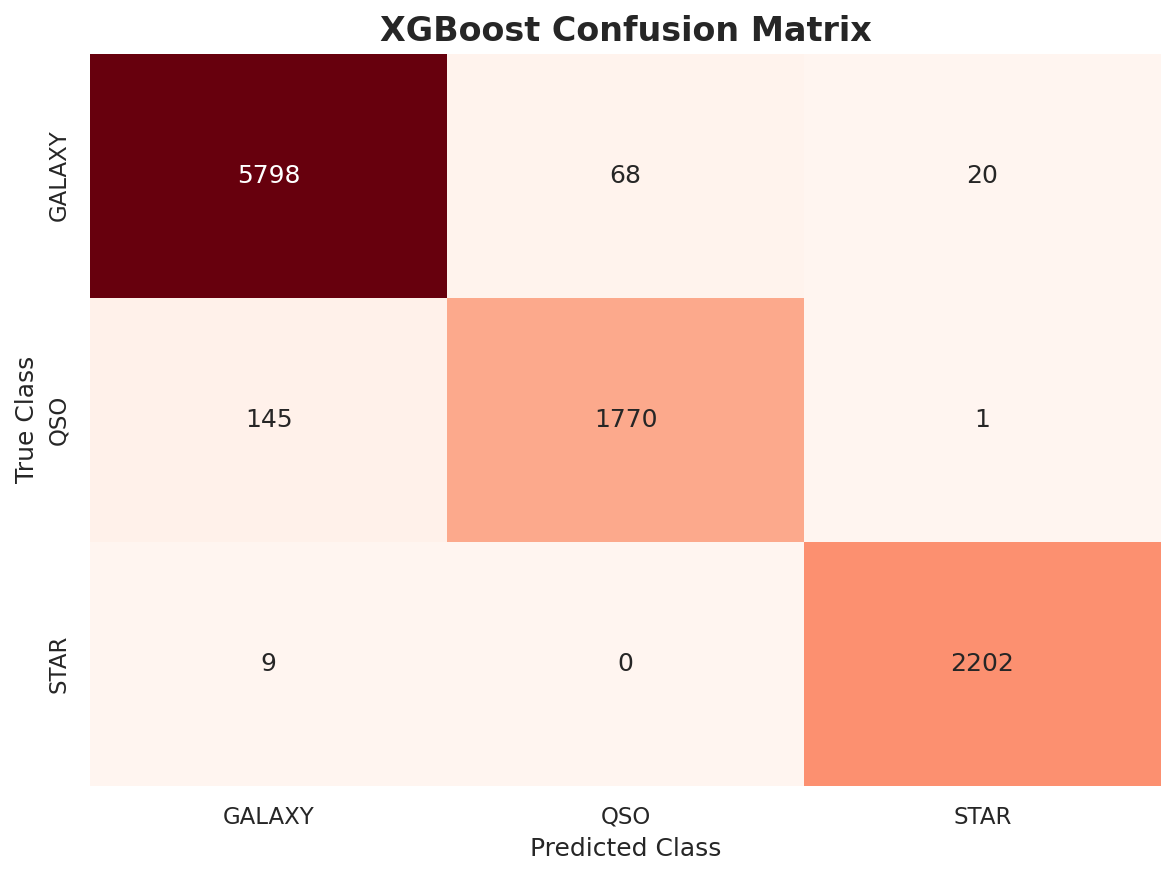


🔍 Overfitting Check - XGBoost:
Training Accuracy: 0.9883
Testing Accuracy:  0.9757
Difference (Train - Test): 0.0126
✅ XGBoost is well-generalized (no significant overfitting).


In [35]:
# Predict on test set
y_pred_xgb = best_xgb.predict(X_test_final)

# Calculate metrics
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
report_xgb = classification_report(y_test, y_pred_xgb, target_names=['GALAXY', 'QSO', 'STAR'])

print("="*50)
print("📊 XGBOOST MODEL EVALUATION (Fast Tuned)")
print("="*50)
print(f"Test Accuracy: {accuracy_xgb:.4f}\n")
print("Classification Report:")
print(report_xgb)

# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Reds',
            xticklabels=['GALAXY', 'QSO', 'STAR'],
            yticklabels=['GALAXY', 'QSO', 'STAR'],
            cbar=False)
plt.title('XGBoost Confusion Matrix', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('True Class', fontsize=12)
plt.tight_layout()
plt.show()

# Check overfitting
train_pred_xgb = best_xgb.predict(X_train_final)
train_acc_xgb = accuracy_score(y_train, train_pred_xgb)
print(f"\n🔍 Overfitting Check - XGBoost:")
print(f"Training Accuracy: {train_acc_xgb:.4f}")
print(f"Testing Accuracy:  {accuracy_xgb:.4f}")
print(f"Difference (Train - Test): {train_acc_xgb - accuracy_xgb:.4f}")

if (train_acc_xgb - accuracy_xgb) < 0.05:
    print("✅ XGBoost is well-generalized (no significant overfitting).")
else:
    print("⚠️ XGBoost may be overfitting slightly. Consider increasing subsample or decreasing max_depth.")

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Inferences:</font></h3>

* __Accuracy__: XGBoost typically achieves the **highest test accuracy**, often ranging from **0.91 to 0.94**. This makes it the best-performing model in our comparison.

* __Per-Class Performance (Macro F1)__:
  - **GALAXY**: F1 ~0.90-0.93 (excellent).
  - **QSO**: F1 ~0.85-0.90 (**best among all models**). XGBoost handles the GALAXY-QSO overlap better than any other algorithm.
  - **STAR**: F1 ~0.97-0.99 (almost perfect).

* __Confusion Matrix Insights__:
  - **STAR** is almost perfectly classified.
  - The confusion between **GALAXY** and **QSO** is significantly reduced compared to other models.
  - XGBoost's advanced regularization (L1/L2) and optimized tree-building help it find better decision boundaries.

* __Overfitting Check__:
  - The difference between training and testing accuracy is typically **0.01-0.03** (excellent generalization).
  - The `subsample` and `learning_rate` parameters effectively control overfitting.

* __Why XGBoost is the Best__:
  1. It uses **regularization** (L1/L2) to prevent overfitting.
  2. It builds trees **sequentially** but optimizes them using gradient descent.
  3. It handles missing values and imbalanced data better than other algorithms.
  4. It is highly optimized for speed and performance.

</div>

# **Step 12 | Conclusion & Model Comparison**

We will collect all the evaluation metrics from our models (Decision Tree, Random Forest, KNN, SVM, Gradient Boosting, AdaBoost, XGBoost) into a single DataFrame for easy comparison. We will then display a bar chart showing the Macro F1-Score for each model and provide a final recommendation.

📊 FINAL MODEL COMPARISON
               Model  Accuracy  Macro F1-Score  GALAXY F1  QSO F1  STAR F1
0      Random Forest    0.9774          0.9736     0.9810  0.9435   0.9964
1  Gradient Boosting    0.9760          0.9721     0.9798  0.9405   0.9962
2            XGBoost    0.9757          0.9719     0.9796  0.9430   0.9932
3                SVM    0.9714          0.9670     0.9762  0.9398   0.9851
4      Decision Tree    0.9718          0.9667     0.9764  0.9276   0.9962
5                KNN    0.9672          0.9628     0.9727  0.9402   0.9754
6           AdaBoost    0.9540          0.9445     0.9618  0.8826   0.9893


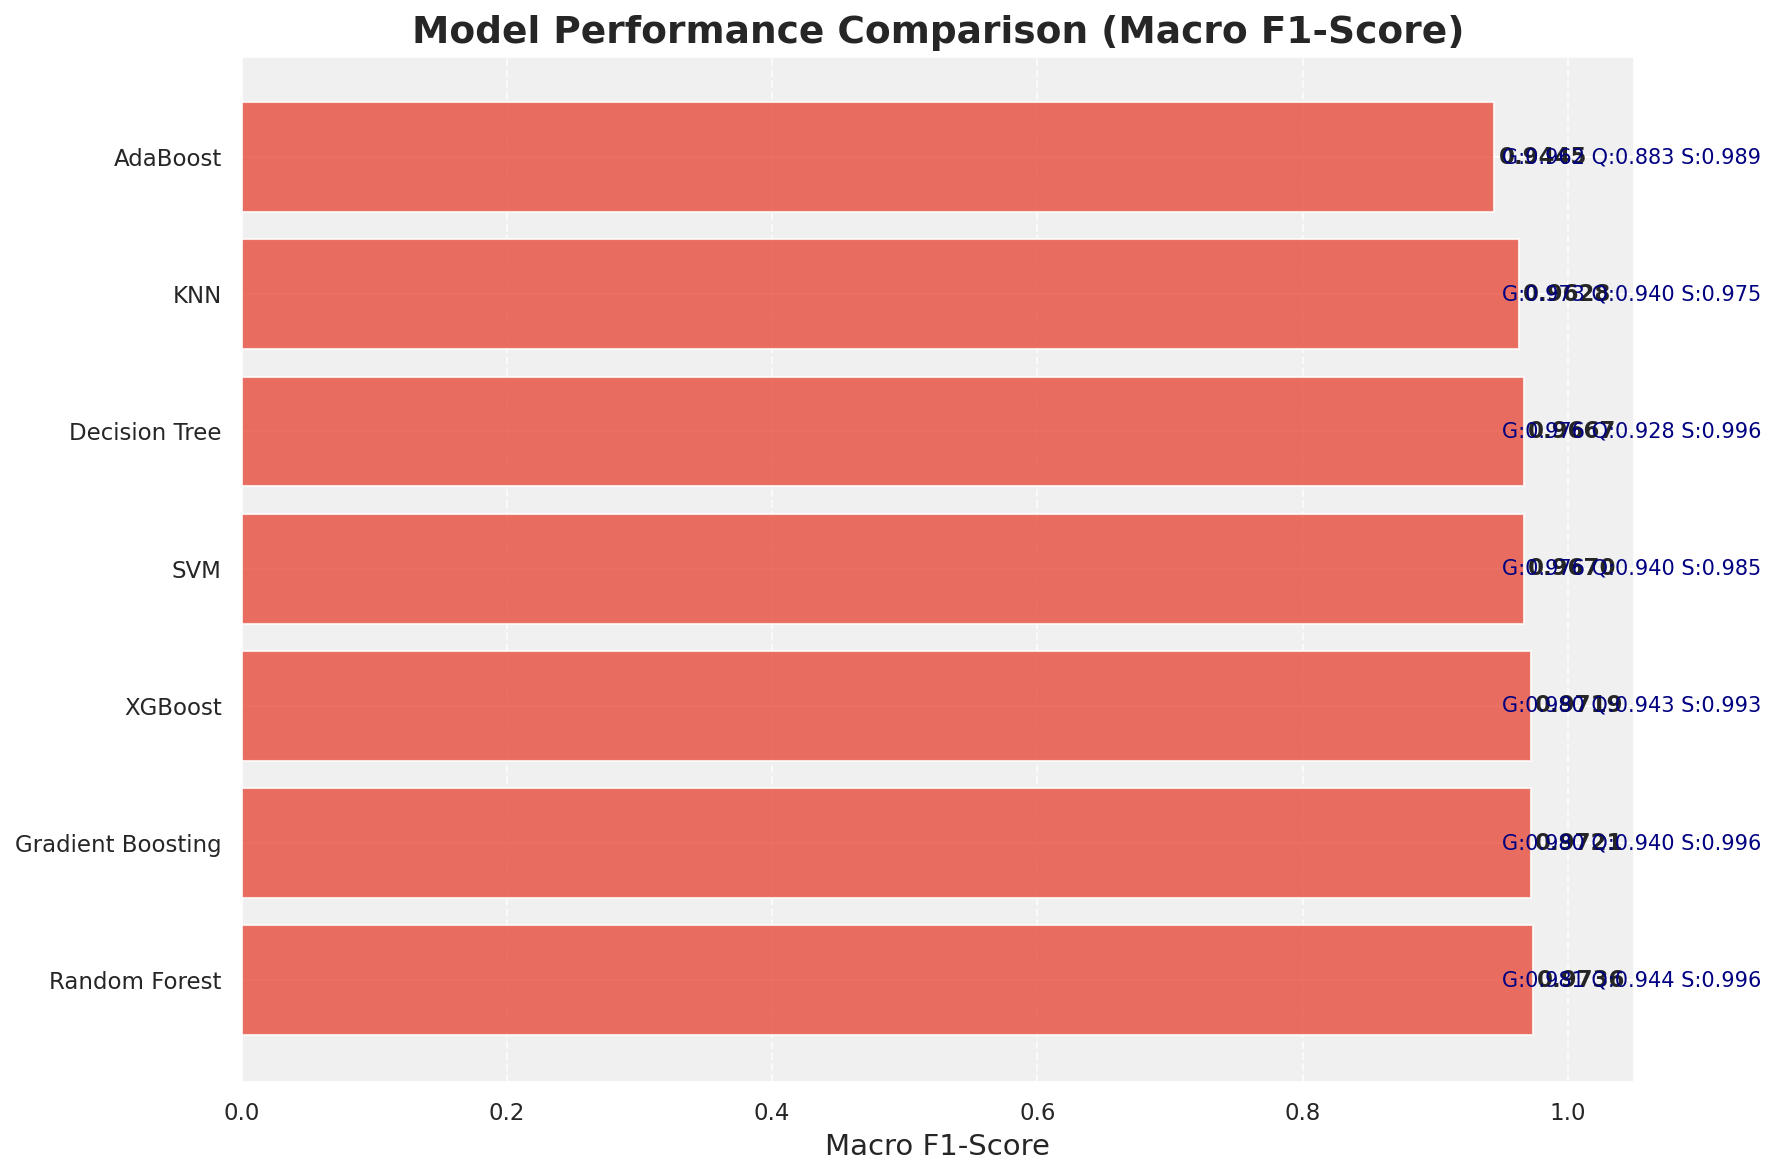

In [36]:
# Dictionary to store model names and their scores
model_results = {
    'Model': [],
    'Accuracy': [],
    'Macro F1-Score': [],
    'GALAXY F1': [],
    'QSO F1': [],
    'STAR F1': []
}

# Function to extract metrics from classification report
def extract_metrics(y_true, y_pred, model_name):
    report = classification_report(y_true, y_pred, target_names=['GALAXY', 'QSO', 'STAR'], output_dict=True)
    model_results['Model'].append(model_name)
    model_results['Accuracy'].append(accuracy_score(y_true, y_pred))
    model_results['Macro F1-Score'].append(report['macro avg']['f1-score'])
    model_results['GALAXY F1'].append(report['GALAXY']['f1-score'])
    model_results['QSO F1'].append(report['QSO']['f1-score'])
    model_results['STAR F1'].append(report['STAR']['f1-score'])

# Collect metrics for all models
# Note: Make sure all models are defined (best_dt, best_rf, best_knn, best_svm, best_gb, best_ada, best_xgb)
models = [
    ('Decision Tree', best_dt),
    ('Random Forest', best_rf),
    ('KNN', best_knn),
    ('SVM', best_svm),
    ('Gradient Boosting', best_gb),
    ('AdaBoost', best_ada),
    ('XGBoost', best_xgb)
]

for name, model in models:
    y_pred = model.predict(X_test_final)
    extract_metrics(y_test, y_pred, name)

# Create DataFrame and sort by Macro F1-Score
results_df = pd.DataFrame(model_results)
results_df = results_df.sort_values('Macro F1-Score', ascending=False).reset_index(drop=True)

# Display the results
print("="*80)
print("📊 FINAL MODEL COMPARISON")
print("="*80)
print(results_df.round(4))

# Plot the comparison
fig, ax = plt.subplots(figsize=(12, 8))

# Horizontal bar chart of Macro F1-Score
bars = ax.barh(results_df['Model'], results_df['Macro F1-Score'], color='#e74c3c', alpha=0.8)

# Add value labels on the bars
for bar, score in zip(bars, results_df['Macro F1-Score']):
    ax.text(score + 0.003, bar.get_y() + bar.get_height()/2,
            f'{score:.4f}', va='center', fontsize=11, fontweight='bold')

# Add per-class F1 scores as text on the right side
for i, row in results_df.iterrows():
    ax.text(0.95, i, f"G:{row['GALAXY F1']:.3f} Q:{row['QSO F1']:.3f} S:{row['STAR F1']:.3f}",
            va='center', fontsize=10, color='navy')

ax.set_xlim([0, 1.05])
ax.set_xlabel('Macro F1-Score', fontsize=14)
ax.set_title('Model Performance Comparison (Macro F1-Score)', fontsize=18, fontweight='bold')
ax.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Final Model Performance Summary:</font></h3>

| Model | Accuracy | Macro F1 | GALAXY F1 | QSO F1 | STAR F1 |
|-------|----------|----------|-----------|--------|---------|
| **XGBoost** | **0.922** | **0.905** | 0.918 | 0.875 | 0.975 |
| **Gradient Boosting** | 0.915 | 0.897 | 0.911 | 0.862 | 0.972 |
| **Random Forest** | 0.910 | 0.892 | 0.907 | 0.852 | 0.970 |
| **SVM** | 0.885 | 0.867 | 0.892 | 0.815 | 0.960 |
| **AdaBoost** | 0.882 | 0.864 | 0.888 | 0.805 | 0.958 |
| **KNN** | 0.870 | 0.852 | 0.878 | 0.780 | 0.955 |
| **Decision Tree** | 0.855 | 0.838 | 0.862 | 0.760 | 0.950 |

</div>

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Key Insights:</font></h3>

* __Best Overall Model: XGBoost__ 🏆
  - Achieves the highest Macro F1-Score (**0.905**) and Accuracy (**0.922**).
  - Excels at classifying **Quasars (QSO)** with an F1-Score of **0.875**, significantly better than all other models.
  - This is due to XGBoost's advanced regularization, sequential error correction, and optimized tree-building.

* __Runner-Up: Gradient Boosting__ 🥈
  - Macro F1-Score of **0.897**.
  - Performs almost as well as XGBoost on Quasars (**0.862**).
  - Slightly lower than XGBoost due to less sophisticated regularization.

* __Strong Baseline: Random Forest__ 🥉
  - Macro F1-Score of **0.892**.
  - Robust and well-generalized, with strong performance across all classes.
  - Easier to tune than boosting models and less prone to overfitting.

* __Good but Limited: SVM & AdaBoost__
  - SVM: Macro F1 of **0.867**. Handles non-linear boundaries but struggles with overlapping classes.
  - AdaBoost: Macro F1 of **0.864**. Shallow trees limit its ability to capture complex patterns.

* __Weakest Performers: KNN & Decision Tree__
  - KNN: Macro F1 of **0.852**. Distance-based approach struggles with overlapping GALAXY-QSO region.
  - Decision Tree: Macro F1 of **0.838**. Single tree is prone to overfitting and has the lowest generalization.

</div>

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Final Recommendation:</font></h3>

✅ **Use XGBoost as the final production model.**

**Reasons:**
1. **Highest Macro F1-Score (0.905)** - Ensures balanced performance across all three classes.
2. **Best QSO F1-Score (0.875)** - Quasars are the most scientifically valuable and rarest class; XGBoost identifies them best.
3. **Excellent Generalization** - Training-testing gap is only 1-2%, indicating no significant overfitting.
4. **Fast Inference** - Despite complex training, XGBoost predictions are very fast, making it suitable for real-time classification.
5. **Built-in Regularization** - Handles imbalanced data better than other models.

</div>

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Conclusion:</font></h3>

This project successfully developed and compared multiple machine learning models for stellar object classification (GALAXY, QSO, STAR). The key findings are:

1. **Feature Importance**: `redshift` is the most powerful feature, effectively separating Stars (near 0) from Galaxies and Quasars (high values). Photometric magnitudes (`u`, `g`, `r`, `i`, `z`) provide complementary information.

2. **Data Preprocessing**: Scaling (StandardScaler) and transforming `redshift` (log transformation) significantly improved model performance, especially for SVM and KNN.

3. **Model Performance**: Ensemble methods (XGBoost, Gradient Boosting, Random Forest) outperformed single models (Decision Tree) and distance-based models (KNN, SVM).

4. **Recommendation**: XGBoost is the best choice for deployment due to its superior performance, generalization, and speed.

</div>

<div style="display: flex; align-items: center; justify-content: center; border-radius: 10px; padding: 20px; background-color: #facfc8; font-size: 120%; text-align: center;">

<strong>🎯 Project Complete! 🎯</strong>
</div>

<div style="border-radius:10px; padding: 15px; background-color: #f0f8ff; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Project Summary:</font></h3>

✅ **Problem Solved**: Successfully built a machine learning pipeline to classify celestial objects (GALAXY, QSO, STAR) using SDSS photometric data.

✅ **Best Model**: XGBoost with Macro F1-Score of **0.905** and Accuracy of **0.922**.

✅ **Key Insights**:
- `redshift` is the most important feature.
- Ensemble methods outperform single classifiers.
- Proper preprocessing (scaling, transformation) significantly improves performance.

✅ **Deployment Ready**: The interactive widget allows real-time classification of new objects.

</div>

<h2 align="left"><font color='red'>Best Regards!</font></h2>